# Appendix F — Calculus tutorial

Calculus is the study of the properties of functions.
We use calculus to describe the limit behaviour of functions,
calculate their rates of change, and calculate the areas under their graphs.
In this tutorial,
you'll learn about all these operations through math formulas,
interactive visualizations,
and code examples.

Click the binder button [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/minireference/noBSstats/HEAD?labpath=tutorials/calculus_tutorial.ipynb) or this link [`bit.ly/calctut3`](https://bit.ly/calctut3) to run this notebooks interactively.

### Notebook setup

In [1]:
%pip install --quiet  sympy numpy scipy seaborn ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (5, 1.7)},
)
%config InlineBackend.figure_format = 'retina'

# simple float __repr__
np.set_printoptions(legacy='1.25', threshold=100)

In [3]:
from sympy import init_printing
init_printing()

## Introduction


### Example: car trip

Suppose you're driving to see a friend in a neighbouring town. The total
length of the journey is 27000 m (27 km) along a straight road. We can
describe your position over time as a function $x(t)$, and use the car's
trip odometer to measure the distance travelled. Right before you leave,
which we'll call $t=0$, you reset the trip odometer so it reads
$x(0)=0$ m.

### Velocity

The *derivative function* $x^{\prime\!}(t)$, pronounced "$x$ prime,"
describes how the function $x(t)$ changes over time. In this example
$x^{\prime\!}(t)$ is the car's *velocity*. If your current velocity is
$x^{\prime\!}(t)=15$ m/s, then the car's position $x(t)$ is increasing
by $15$ m each second. If you maintain this velocity, the position will
increase at a constant rate: $x(0)=0$ m, $x(1)=15$ m, $x(2)=30$ m, and
so on until $t=1800$ s when you'll have travelled
$1800\times 15 = 27000$ m and reached your destination.

To estimate the time remaining in the trip, assuming the velocity
$x^{\prime\!}(t)$ stays constant, you can divide the remaining distance
by the current velocity: $$\text{time remaining at } t
                    \; \; =\; \frac{ 27000 - x(t) }{ x^{\prime\!}(t) } \;\;\; \textrm{s}.$$
The bigger the derivative $x^{\prime\!}(t)$, the faster you'll arrive.
If you drive two times faster, the time remaining will be halved.

### Inverse problem

Imagine that the car's odometer is busted
and you don't have any way to measure the distance $x(t)$
you have travelled over time.
The car's speedometer is still working though,
so you know the velocity $x^{\prime\!}(t)$ at all times.
Is there a way to calculate the distance travelled
using only the information from the speedometer?

There is!
You can infer the position at time $t$ from the velocity $x^{\prime\!}(t)$.
Think about it---if the speedometer reports $x^{\prime\!}(t)=15$ m/s,
then you know that the car's position
is increasing at the rate of $15$ m each second.
We can describe the total distance travelled until time $t=\tau$
(the Greek letter *tau*) as the *integral* of the velocity function $x^{\prime\!}(t)$ between $t=0$ and $t=\tau$:
$$
   x(\tau) \; = \; \int_{t=0}^{t=\tau}  x^{\prime\!}(t)\, dt.
$$

The integral symbol $\int$ is an elongated $S$ that stands for *sum*. To
calculate the total distance travelled, we imagine splitting the time
between $t=0$ and $t=\tau$ into many short time intervals $dt$. During
each instant, the position increases by $x^{\prime\!}(t)dt$ m, where
$x^{\prime\!}(t)$ is the velocity (measured in m/s),
and $dt$ is the time interval (measured in seconds).
The integral $\int_{0}^{\tau} x^{\prime\!}(t)\, dt$
calculates the "sum" of these $x^{\prime\!}(t)\,dt$ contributions
accumulated between $t=0$ and $t=\tau$.

The situation described in the car example
shows that calculus concepts are not theoretical constructs
reserved only for math specialists,
but common ideas you encounter every day.
The derivative $q^{\prime\!}(t)$
describes the rate of change of the quantity $q(t)$.
The integral $\int_a^b q(t)dt$
measures the total accumulation of the quantity $q(t)$
during the time period from $t=a$ to $t=b$.

### Doing calculus: then and now

#### Symbolic calculations using pen and paper

The pen-and-paper approach is a good way to learn calculus
because manipulating math symbols "by hand"
develops your intuitive understanding of calculus procedures.
Writing math on paper
allows you to use high-level abstractions
and arrive at exact symbolic answers.


#### Symbolic calculations using SymPy

The Python library SymPy allows you to do symbolic math calculations on a computer.
We'll now illustrate the main SymPy capabilities through some examples.

To use SymPy,
we start by importing the `sympy` module under the alias `sp`,
then define the symbolic variable `x`.

In [4]:
import sympy as sp

# define symbolic variable x
x = sp.symbols("x")

The `symbols` function creates SymPy symbolic variables.
Unlike ordinary Python variables that hold a particular value,
SymPy variables act as placeholders that can take on any value.
We use symbolic variables to write  expressions,
just like we do in pen-and-paper calculations.

In [5]:
expr = 4 - x**2
expr

SymPy is very useful when learning math
because it provides functions for common math operations.
For example,
to *factor* the expression `expr`,
we can call the function `sp.factor`.

In [6]:
sp.factor(expr)

You can substitute a particular `<value>` for the variable $\tt{x}$
into the expression `expr` by calling the method `expr.subs()`
and passing in a python dictionary object `{x:<value>}`.

In [7]:
expr.subs({x:1})

We can also also ask SymPy to *solve* the equation `expr = 0`,
which means to find the values of $x$ that satisfy the equation $4 - x^2 = 0$.

In [8]:
sp.solve(expr, x)

The equation has two solutions so `solve` returns a list.

<!-- The function `solve` is the main workhorse in `SymPy`. This incredibly
powerful function knows how to solve all kinds of equations. In fact
`solve` can solve pretty much any equation! When high school students
learn about this function, they get really angry&mdash;why did they spend
five years of their life learning to solve various equations by hand,
when all along there was this `solve` thing that could do all the math
for them? Don't worry, learning math is never a waste of time.

The function `solve` takes two arguments. Use `solve(expr,var)` to
solve the equation `expr==0` for the variable `var`. You can rewrite any
equation in the form `expr==0` by moving all the terms to one side
of the equation; the solutions to $A(x) = B(x)$ are the same as the
solutions to $A(x) - B(x) = 0$. 
-->

Here is another example,
where we use `sp.solve` to solve the quadratic equation $x^2 + 2x - 8 = 0$.

In [9]:
sp.solve(x**2 + 2*x - 8, x)

We can check that $x = 2$ and $x = -4$ satisfy the equation $x^2 + 2x - 8 = 0$:
- When $x = 2$, we get $x^2 + 2x - 8 =(2)^2 + 2(2) - 8 = 4  + 4 - 8 = 0$.
- When $x = -4$, we get $x^2 + 2x - 8 =(-4)^2 + 2(-4) - 8 = 16  - 8 - 8 = 0$.

Another useful function is `sp.simplify`,
which you can use to simplify any math expression.

In [10]:
sp.simplify(5*x - 3*x + 42)

SymPy combined the $5x$ term with the $-3x$ term
to obtain the $2x$ term in the simplified output expression.

Sum{y can do many other math operations.
We'll discuss the SymPy functions for doing calculus in the next sections.
To learn more about SymPy,
I invite you to check out the [SymPy tutorial](https://minireference.com/static/tutorials/sympy_tutorial.pdf).

#### Numerical computing using NumPy

The Python library NumPy makes it easy to do numerical calculations on a computer.
Let's start by importing the `numpy` module under the alias `np`,
which is the usual convention.

In [11]:
import numpy as np

Her is how e can compute a numerical approximation to $\sqrt{2}$.

In [12]:
np.sqrt(2)

NumPy makes it easy to work with arrays of numbers,
which are conceptually similar to Python lists,
but enable powerful parallel calculations.
To give you some idea of this power,
we'll now show create an array of 1001 numbers,
and apply a function to each input in this array,
to obtain an array of 1001 outputs
using just a few lines of code.

We start by calling the NymPy function `np.linspace` to create the array of smoothly varying inputs.
We specify the starting point `0`,
the end point `2`,
and number of values we want in the array.

In [13]:
xs = np.linspace(0, 2, 1001)
xs

array([0.   , 0.002, 0.004, ..., 1.996, 1.998, 2.   ])

Next,
we define a Python function `h`
that corresponds to the math function $h(x) = 4 - x^2$.

In [14]:
def h(x):
    return 4 - x**2

We can now apply this function to the array of inputs `xs`
to obtain an array of outputs `hxs`.

In [15]:
%%time
hxs = h(xs)
hxs

CPU times: user 34 μs, sys: 17 μs, total: 51 μs
Wall time: 42.9 μs


array([4.      , 3.999996, 3.999984, ..., 0.015984, 0.007996, 0.      ])

Note that single call to `h(xs)`
applied the function `h` to all 1001 inputs in the array `xs` at once.
This is called *vectorization*,
and one of the great powers of NumPy:
we can write simple math expression that describe
what we want to do for each input `x`,
and then NumPy performs these mathematical operations on entire arrays at once,
eliminating the need for writing `for`-loops.

Using NumPy vectorization not only makes numeric code easier to read,
but also also makes it run faster!
To illustrate this speed up,
let's look at the equivalent Python code
for applying `h` to the list of inputs using Python.

In [16]:
%%time
# Create a list of inputs `xs_list`
xs_list = [0.002*i for i in range(0, 1001)]

# Apply the function `h` to each input in the list `xs_list`
hxs_list = [h(x) for x in xs_list]

# Display the first three and last three values in `hxs_list`
print(*hxs_list[0:3], "...", *hxs_list[-3:])

4.0 3.999996 3.999984 ... 0.015983999999999998 0.007995999999999892 0.0
CPU times: user 244 μs, sys: 18 μs, total: 262 μs
Wall time: 258 μs


Comparing the timing information output of this cell
to the timing information shown earlier,
we see that the basic Python version took roughly 10 times longer than the NymPy code.

#### Scientific computing using SciPy

The Python module SciPy is a toolbox of scientific computing helper functions.
For example,
computing the integral $\int_{0}^2 h(x)dx$,
which corresponds to the area under the graph of the function $h(x) = 4 - x^2$
between $x=0$ and $x=2$ requires only two lines of code.

In [17]:
from scipy.integrate import quad
quad(h, 0, 2)[0]

The helper function `quad` is a powerful tool
that the ancients could only dream of.

### Applications of calculus

We use calculus concepts
to describe various quantities in physics, chemistry, biology, engineering, machine learning, business, economics and other domains where quantitative analysis is used.
Many laws of nature are expressed in terms of derivatives and integrals,
so it's essential that you learn the language of calculus if you want to study science.

## Math prerequisites

Let's start with a review of some key ideas from high school math, which
we'll need as building blocks for calculus.

### Sets notation

Sets are collections of math objects. Many math ideas are expressed in
the language of sets, so it's worth knowing the notation for sets.

-   $\{ \textrm{  definition  } \}$: we use curly brackets to define
    sets. The definition in the curly brackets is either a description
    of the set's contents, or a list of the elements in the set.

-   $\mathbb{N}$: the set of natural numbers
    $\mathbb{N} = \{0,1,2,3,4,5,\ldots\}$.

-   $\mathbb{N}_+$: the positive natural numbers
    $\mathbb{N}_+ = \{1,2,3,4,5,\ldots\}$.

-   $\mathbb{R}$: the set of real numbers.

-   $\mathbb{R}_+$: the set of nonnegative real numbers.

-   $x \in S$: this statement is read "$x$ is an element of $S$." We use
    this notation to indicate the "type" of the variable $x$. For
    example, writing "$x \in \mathbb{R}$" tells us $x$ is a real number.

We can use the *set-builder* notation $\{\, \cdot \; | \;  \cdot \, \}$
to define new sets. Inside the curly brackets, we first describe the
general kind of mathematical objects we are talking about, followed by
the symbol "$|$" (which stands for "such that"), followed by the
conditions that identify the elements of the set. For example, the set
of nonnegative real numbers $\mathbb{R}_+$ is defined as "all real
numbers $x$ such that $x \geq 0$," which is expressed compactly as
$\mathbb{R}_+ = \{ x \in \mathbb{R} \; | \; x \geq 0 \}$ using the
set-builder notation.

#### Python sets

In [18]:
S = {1, 2, 3}
T = {3, 4, 5, 6}

The statement $x \in S$ means $x$ is one of the elements of the set $S$.

In Python, we can use the `in` operator to check if a value is inside the set.

In [19]:
1 in S

True

The `in` statement returns `False` for a value that are not in the set.

In [20]:
7 in S

False

We can perform set operations like *union*,
*intersection*, and *set difference* as follows:

In [21]:
print("S ∪ T =", S.union(T))
print("S ∩ T =", S.intersection(T))
print("S \\ T =", S.difference(T))

S ∪ T = {1, 2, 3, 4, 5, 6}
S ∩ T = {3}
S \ T = {1, 2}


#### The number line

The *number line* is a visual representation of the set of real numbers $\mathbb{R}$

![The number line showing equally spaced notches](./attachments/calculus/number_line_rationals_and_reals.png)

The set of real numbers includes the natural numbers
$\{0,1,2,3,\ldots\}$, the integers
$\{\ldots, -3,-2,-1,0,1,2,3,\ldots\}$, rational numbers like
$-\frac{3}{2}$, $0.5$, and $\frac{9}{2}$, as well as irrational numbers
like $\sqrt{2}$, $e$, and $\pi$. All the numbers you will run into when
doing math can be visualized as a point on the number line.

#### Infinity


The math symbol $\infty$ describes the concept of *infinity*. We use
$\infty$ to represent an infinitely large quantity, that is greater than
any number you can think of. Geometrically speaking, you can imagine the
number line extends to the right forever towards infinity, as
illustrated in the number line figure above.
The number line also extends forever to the left, which we denote as negative infinity $-\infty$.

Infinity is not a number but a *process*. When we use the symbol
$+\infty$, we're describing the process of moving to the right on the
number line *forever*. We go past larger and larger positive numbers and
never stop.

Infinity is a key concept in calculus, so it's important that we develop
a precise language to talk about infinitely large numbers and procedures
with an infinite number of steps, which we'll do in the section on limits below.

### Functions

In Python, we define functions using the `def` keyword.
For example, the code cell below defines the function $f(x) = x^2$,
then evaluate it for the input $x=3$.

In [22]:
# Define the function `f`
def f(x):
    return x**2

# Call the function `f` on the input x=3
f(3)

#### Function graphs

The graph of the function $f(x)$ is obtained by plotting a curve
that passes through the set of input-output coordinate pairs $(x, f(x))$,
as $x$ varies over a range of inputs.

In [23]:
import numpy as np
xs = np.linspace(-3, 3, 1001)
fxs = f(xs)

The function `linspace(-3,3,1001)`
creates an array of `1001` points in the between $-3$ and $3$.
We store this sequence of inputs into the variable `xs`.
Next, we compute the output value $f(x)$ for each of the inputs $x$ in the array `xs`
and store the result in the array `fxs`.

We can now use the function `sns.lineplot()` to generate the plot.

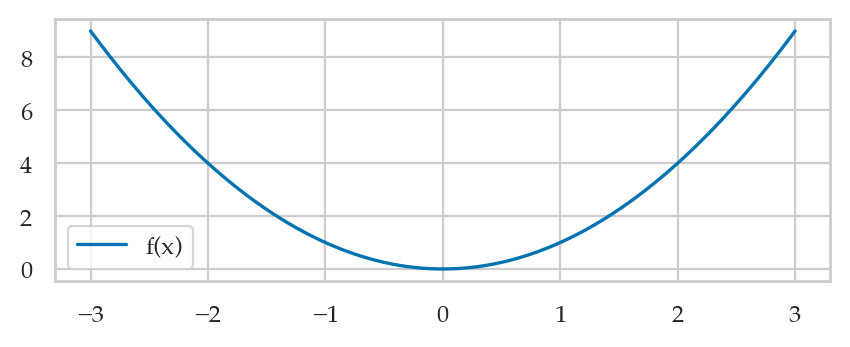

In [24]:
import seaborn as sns
sns.lineplot(x=xs, y=fxs, label="f(x)");

The helper function `plot_func` from the `ministats` library 
performs the same three steps and produces the same output.

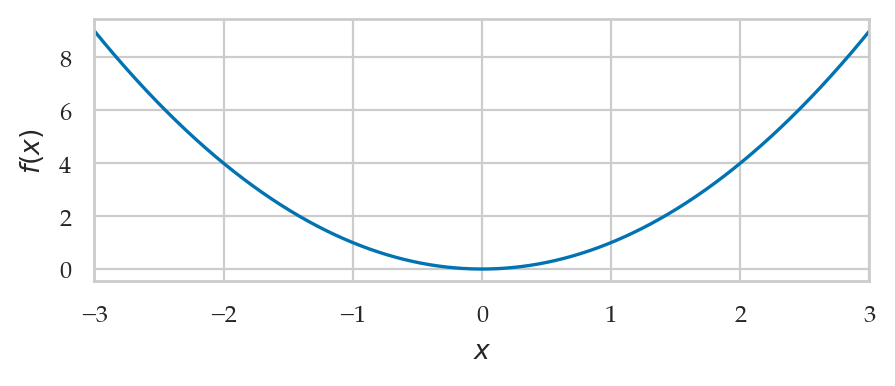

In [25]:
from ministats.calculus import plot_func

plot_func(f, xlim=[-3,3]);

#### Inverse functions

The inverse function $f^{-1}$
performs the *inverse operation* of the function $f$.
If you start from some number $x$,
apply $f$,
then apply $f^{-1}$,
you'll arrive—full circle—back to the original number $x$:

$$
    f^{-1}\!\big( \; f(x) \; \big) = x.
$$


The inverse of the function $f(x) = x^2$
is the square root function $f^{-1}(x) = \sqrt{x}$.
Earlier we computed $f(3) = 9$.
If we apply the inverse function to $9$,
we get $f^{-1}(9) = \sqrt{9} = 3$.

In [26]:
from math import sqrt
sqrt(9)

Two other important inverse functions are the exponential function $e^x$ and logarithmic functions $\log(x)$.
The logarithmic function $\log(x)$
is the inverse of the exponential function $e^x$, and vice versa.
If we compute the exponential of any number,
then apply the logarithmic function,
we get back the original number.

In [27]:
from math import exp, log
log(exp(5))

Similarly,
if we take the logarithm of any positive number,
then apply the exponential function on the result,
we get back to the original number.

In [28]:
exp(log(4))

#### Function properties

We use the notation $f \colon A \to B$ to denote a function from the input
set $A$ to the output set $B$. 

- $A$ is the *domain* of $f$: the set of allowed inputs for the function.
- $B$ is the *image* of $f$: the set of possible outputs of the function.

For example, the domain of the function
$f(x) = x^2$ is $\mathbb{R}$ (any real number) and its image is
$\mathbb{R}_+$ (nonnegative real numbers), so we say $f$ is a function
of the form $f \colon \mathbb{R} \to \mathbb{R}_+$.

### Inventory of functions

We'll now go over a few commonly used math functions
and look at their graphs.

#### Constant function

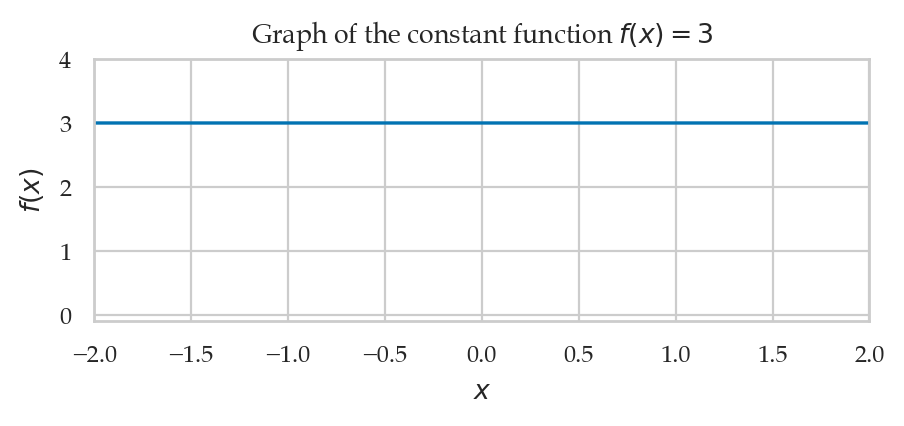

In [29]:
from ministats.calculus import plot_func

def const(x):
    return 3

ax = plot_func(const, xlim=[-2,2])
ax.set_ylim(-0.1, 4)
ax.set_title("Graph of the constant function $f(x) = 3$");

#### Linear function

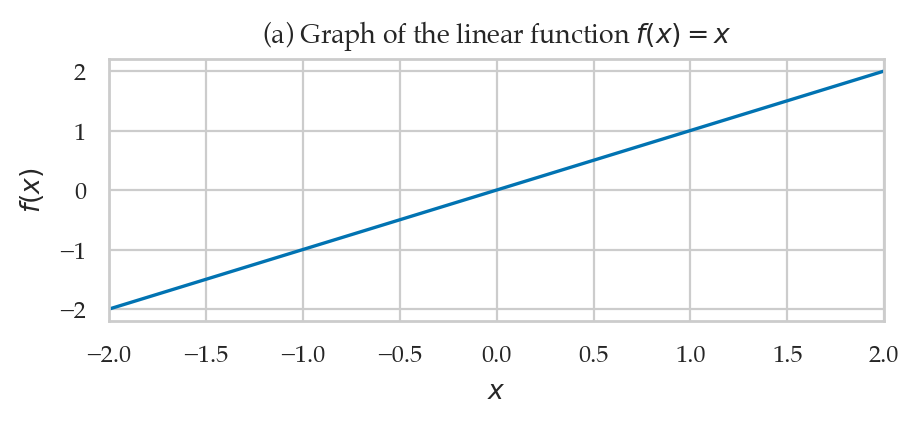

In [30]:
def line(x):
    return x

ax = plot_func(line, xlim=[-2,2])
ax.set_title("(a) Graph of the linear function $f(x) = x$");

#### Quadratic function

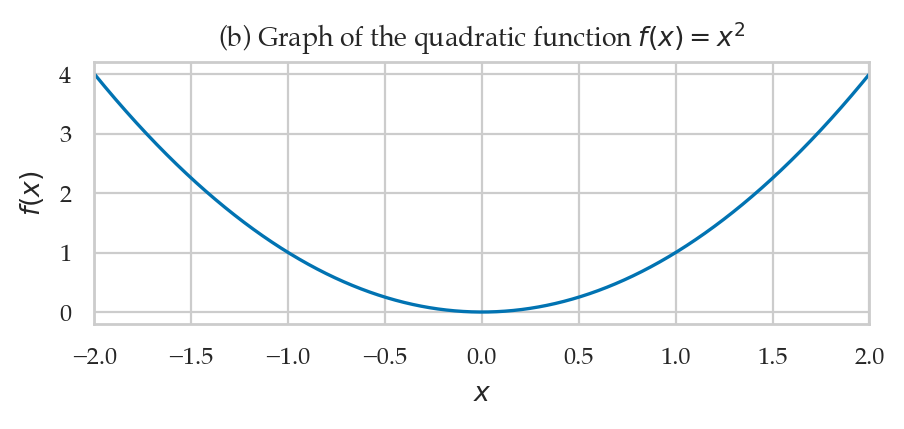

In [31]:
def quadratic(x):
    return x**2

ax = plot_func(quadratic, xlim=[-2,2])
ax.set_title("(b) Graph of the quadratic function $f(x) = x^2$");

#### Polynomial functions

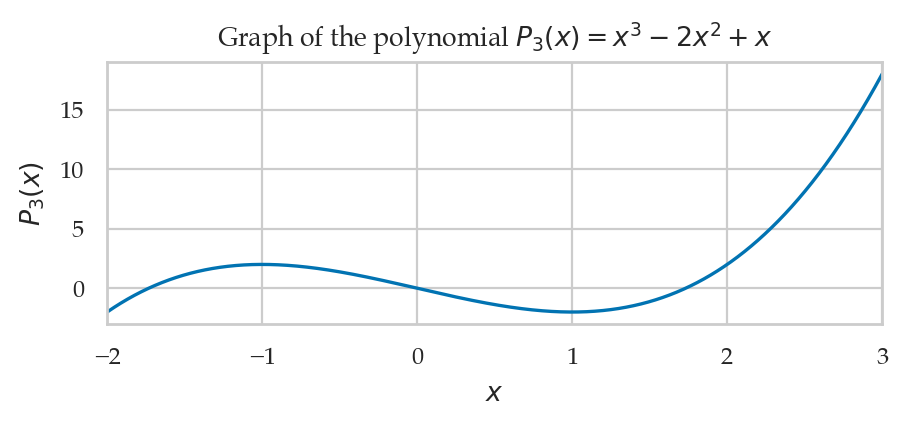

In [32]:
def poly(x):
    return x**3 - 2*x*2 + x

ax = plot_func(poly, xlim=[-2,3], flabel="P_3")
ax.set_title("Graph of the polynomial $P_3(x) = x^3 - 2x^2 + x$");

#### Exponential function

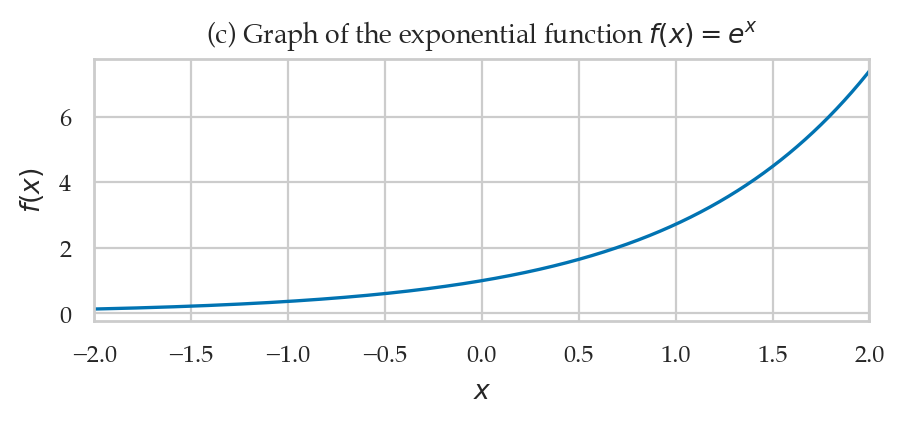

In [33]:
ax = plot_func(np.exp, xlim=[-2,2])
ax.set_title("(c) Graph of the exponential function $f(x) = e^x$");

#### Absolute value function

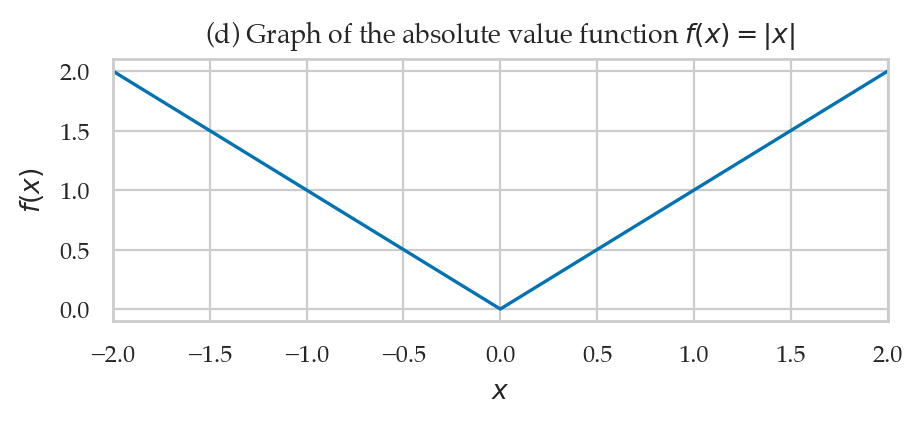

In [34]:
ax = plot_func(np.abs, xlim=[-2,2])
ax.set_title("(d) Graph of the absolute value function $f(x) = |x|$");

#### Square root function

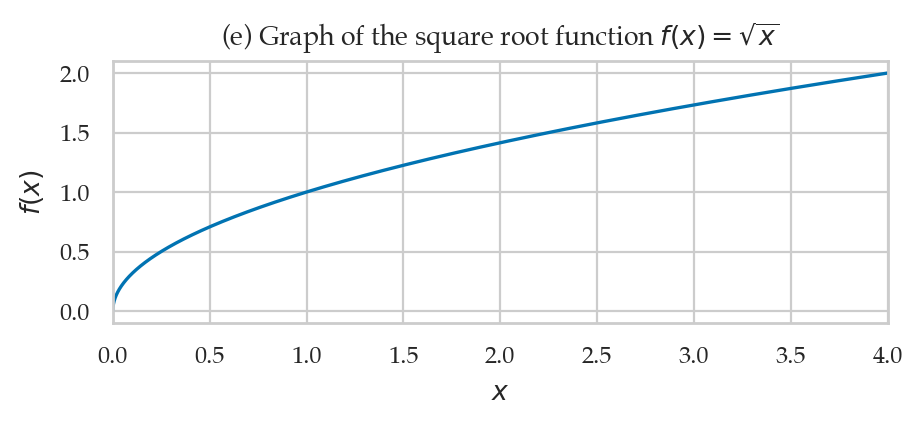

In [35]:
ax = plot_func(np.sqrt, xlim=[0,4])
ax.set_title("(e) Graph of the square root function $f(x) = \\sqrt{x}$");

#### Logarithmic function

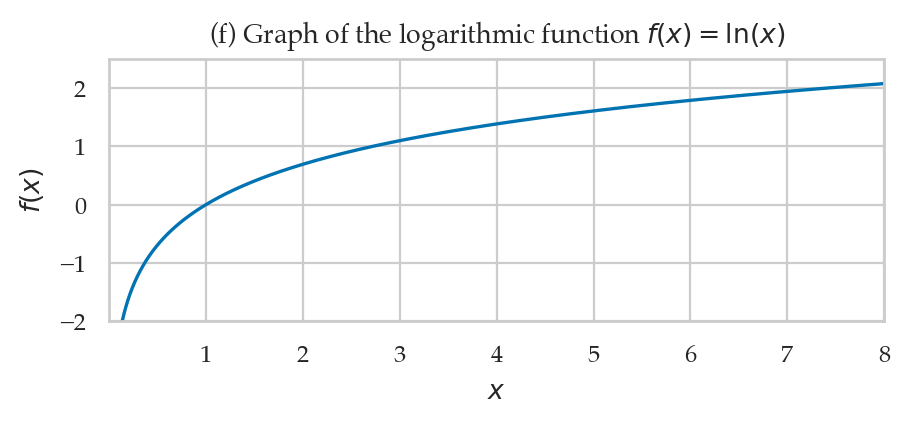

In [36]:
ax = plot_func(np.log, xlim=[0.00001,8])
ax.set_ylim(-2, 2.5)
ax.set_title("(f) Graph of the logarithmic function $f(x) = \\ln(x)$");

### Functions with discrete inputs

Later in this tutorial, we'll study functions with discrete inputs,
$a_k : \mathbb{N} \to \mathbb{R}$, which are called *sequences*.
We can express sequences by writing the first few values the
sequence $[a_0, a_1, a_2, a_3, \ldots]$, which correspond to evaluating
$a_k$ for $k=0$, $k=1$, $k=2$, $k=3$, etc.

### Geometry of rectangles and triangles

The area of a rectangle of base $b$ and height $h$ is $A = bh$.

The area of a
triangle is equal to $\frac{1}{2}$ times the length of its base $b$
times its height $h$: $A = \tfrac{1}{2} b h$.

### Trigonometric functions

The trigonometric functions $\sin\theta$ and $\cos\theta$
are used in physics and engineering.

#### Sine function

The trigonometric functions `np.sin` and `np.cos` take inputs in radians.
For example,
if you need to compute $\sin(\frac{\pi}{6}\;\textrm{rad})$
you can simplay call the function `np.sin`
on the input `np.pi/6`:

In [37]:
np.sin(np.pi/6)

To compute $\sin(30^\circ)$,
you need to fist use the conversion factor of $\frac{\pi\;\textrm{rad}}{180^\circ}$
to convert the angle from degrees to radians.
In angle $\theta = 30^\circ$ is $\theta = 30^\circ \frac{\pi\;\textrm{rad}}{180^\circ}$
in radians.

In [38]:
np.sin(30 * np.pi/180)

Let's plot the graph of $f(\theta) = \sin\theta$ over two full cycles.

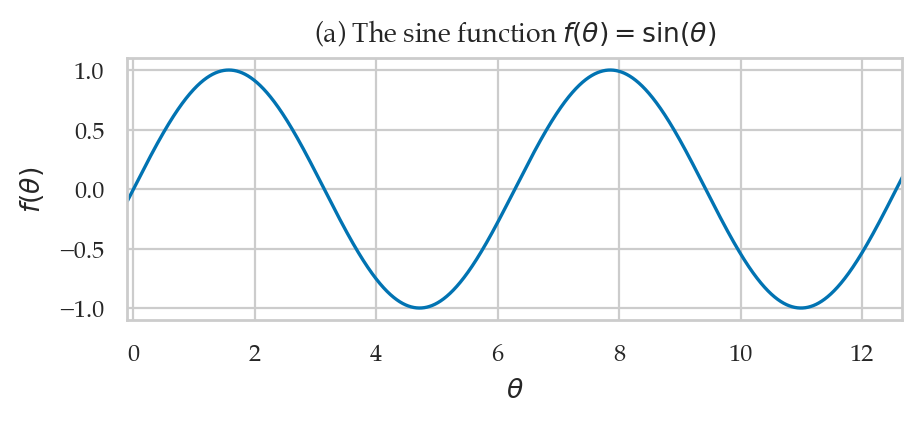

In [39]:
xlim = [-0.1, 4*np.pi+0.1]
ax = plot_func(np.sin, xlim=xlim)
ax.set_title(r"(a) The sine function $f(\theta) = \sin(\theta)$");
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$f(\\theta)$");

#### Cosine function

The cosine function is the same as the sine function shifted by $\frac{\pi}{2}$ to the left:
$f(\theta) = \cos(\theta) = \sin(\theta+\frac{\pi}{2})$.

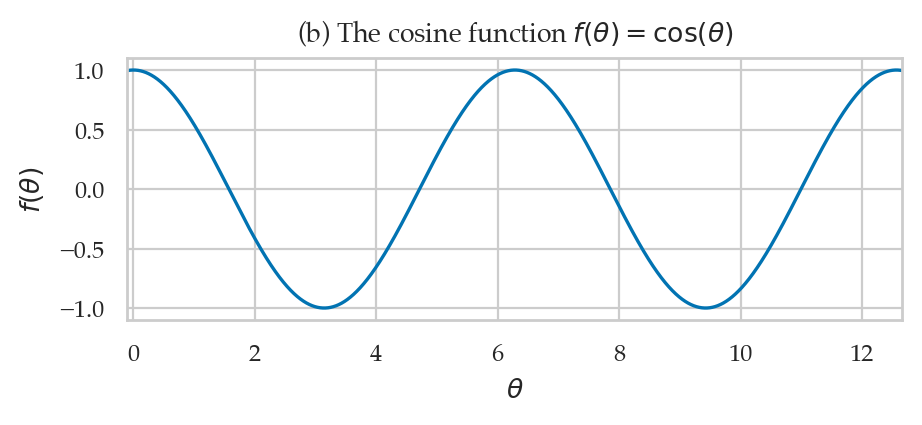

In [40]:
xlim = [-0.1, 4*np.pi+0.1]
ax = plot_func(np.cos, xlim=xlim)
ax.set_title(r"(b) The cosine function $f(\theta) = \cos(\theta)$")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$f(\\theta)$");

### Overview and a look ahead

The concept map below
shows an overview of the calculus ideas you'll learn in the rest of the tutorial.

![Concept maps showing calculus topics ](./attachments/calculus/calculus_tutorial_overview.png)

## Limits

We use limits to describe
infinitely large quantities,
infinitely small quantities,
and procedures with infinitely many steps.
Limits are an essential theoretical building block for calculus.
We use limits to define derivatives, integrals, and series,
so this is where we'll start.

### Example 1: Archimedes' approximation to $\pi$

Suppose we want to calculate the area of a circle of radius $r=1$.
Today we know the formula for the are of the circle is $A_{\circ} = \pi r^2$,
and the area of this circleis $\pi$,
but let's imagine that we're in ancient times and don't know the formula.

Sometime around 250 BCE,
Archimedes of Syracuse came up with a clever idea
to approximate the area of the circle
using a regular polygon with $n$ sides inscribed in the circle.
The figure below shows the hexagonal (6-sides), octagonal (8-sides),
and dodecagonal (12-sides) approximations to the circle.

![Approximations to the area of circle using a hexagon, an octagon, and a dodecagon inscribed inside a circle of radius $r$.](attachments/calculus/inscribed-polygons.png)


Part (b) of the figure highlights one
of the $16$ identical triangular slices for the case $n=8$.
The hypotenuse of this triangle has length $r$,
the angle $\theta$ is $\frac{360\circ}{16} = \frac{2\pi}{16} = \frac{\pi}{8}\,$ rad,
and its sides have length $a=r\cos(\frac{\pi}{8})$
and $b=r\sin(\frac{\pi}{8})$.
The area of this triangle is therefore $A_t = \frac{1}{2}ab=\frac{1}{2}r\cos(\frac{\pi}{8})r\sin(\frac{\pi}{8})$,
and the area of the octagon is $16A_t = 8r^2\cos(\frac{\pi}{8})\sin(\frac{\pi}{8})$.

More generally,
if we draw a polygon with $n$ sides inscribed inside of the circle,
the total area of the $2n$ triangles will be:

$$A(n) = 2n \cdot \tfrac{1}{2}ab 
        = n \, r\cos(\tfrac{\pi}{n})  \, r\sin(\tfrac{\pi}{n})
        = n \, r^2  \cos(\tfrac{\pi}{n})\sin(\tfrac{\pi}{n}).$$
     
The $n$-sided-polygon approximation to the area of the circle
becomes more and more accurate as $n$ grows.
Here is the code for computing the approximations to the area of a
circle with an increasing number of sides.

In [41]:
def calc_area(n, r=1):
    theta = 2 * np.pi / (2 * n)
    a = r * np.cos(theta)
    b = r * np.sin(theta)
    A_n = 2 * n * a * b / 2
    return A_n

for n in [6, 8, 12, 50, 100, 1000, 10000]:
    A_n = calc_area(n)
    error = A_n - np.pi
    print(f"{n=: >6},  A(n)= {A_n:.10f},   {error=:.8f}")

n=     6,  A(n)= 2.5980762114,   error=-0.54351644
n=     8,  A(n)= 2.8284271247,   error=-0.31316553
n=    12,  A(n)= 3.0000000000,   error=-0.14159265
n=    50,  A(n)= 3.1333308391,   error=-0.00826181
n=   100,  A(n)= 3.1395259765,   error=-0.00206668
n=  1000,  A(n)= 3.1415719828,   error=-0.00002067
n= 10000,  A(n)= 3.1415924469,   error=-0.00000021


In the limit as $n \to \infty$, 
the $n$-sided-polygon approximation to the area of the circle 
will becomes *exactly* equal to the area

$$ \lim_{n \to \infty} A(n) = \pi r^2.$$

### Example 2: Euler's number

A load with annual interest rate of 100\%
and compounding twice per year 
will grow by 
$(1+50\%)(1+50\%) = (1+\frac{1}{2})(1+\frac{1}{2}) = 2.25$
by the end of the year:

In [42]:
(1+1/2)**2

If the bank computes the interest three times per year,
the amount owed after one year is
$(1+\frac{1}{3})(1+\frac{1}{3})(1+\frac{1}{3}) = 2.370$.

In [43]:
(1+1/3)**3

With quarterly compounding:

In [44]:
(1+1/4)**4

Monthly compounding:

In [45]:
(1+1/12)**12

Daily compounding:

In [46]:
(1+1/365)**365

Compounding 1000 times per year:

In [47]:
(1+1/1000)**1000

In the limit as $n \to \infty$, 
the expression $(1+\frac{1}{n})^n$
converges to Euler's number $e$:

$$ \lim_{n\to\infty}\left(1+\frac{1}{n}\right)^n
  = e
  = 2.718281828459045235360287471352\ldots.$$


### Limits at infinity

Limits are useful for describing the behaviour of functions.

#### Example 3

Consider the function $f(x) = \frac{1}{x}$.
What happens to $f(x)$ as $x$ goes to infinit?
As $x$ becomes larger and larger,
the fraction $\frac{1}{x}$ becomes smaller and smaller.
In the limit where $x$ goes to infinity,
$\frac{1}{x}$ approaches zero:
$\lim_{x\to\infty}\frac{1}{x} = 0$.
We can see this by looking at the graph of $f(x)$.

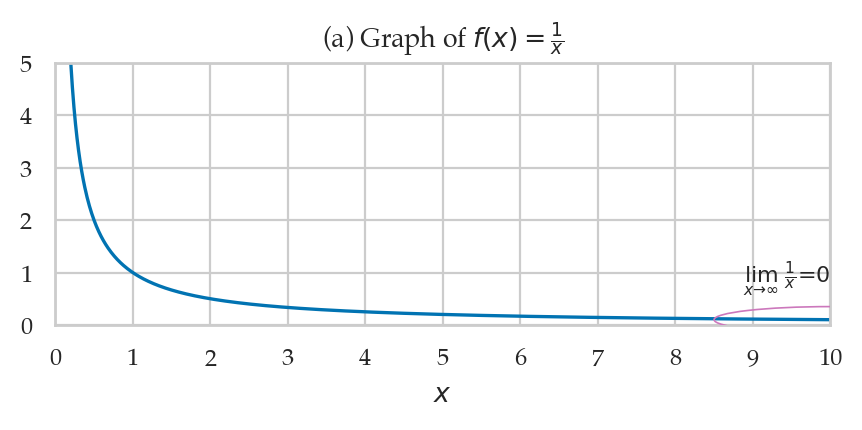

In [48]:
from ministats.calculus import plot_limit
from ministats.calculus import plot_ellipse

# Define the function f(x) = 1/x
def finv(x):
    return 1/x

ax = plot_limit(finv, xlim=[0,10], ylim=[0,5])
ax.set_xticks(range(0,11))
ax.set_xlabel("$x$")
ax.set_title(r"(a) Graph of $f(x) = \frac{1}{x}$")

# Ellipse annotation at x \to \infty
plot_ellipse(ax, 10, 0.1, 3, 0.5, lx=10, ly=0.5, ha="right", va="bottom",
             label=r"$\lim_{x \to \infty}\; \frac{1}{x} = 0$");

### Limit formulas

The limit of the sum, difference, product, and quotient of two functions
are computed as follows:

\begin{align*}	
    \lim_{x \to \infty} (f(x) + g(x)) 	& =  \lim_{x \to \infty} f(x) + \lim_{x \to \infty} g(x), 	\\
    \lim_{x \to \infty} (f(x) - g(x)) 	& =  \lim_{x \to \infty} f(x) - \lim_{x \to \infty} g(x), 	\\
    \lim_{x \to \infty} f(x)g(x) 		& =   \lim_{x \to \infty} f(x) \cdot \lim_{x \to \infty} g(x), \\
    \lim_{x \to \infty} (f(x) / g(x)) & =  \lim_{x \to \infty} f(x) \, / \lim_{x \to \infty} g(x) \, .
    % \lim_{x \to \infty} \frac{f(x)}{g(x)} & =  \frac{ \displaystyle \lim_{x \to \infty} f(x) } { \displaystyle \lim_{x \to \infty} g(x)} \, .
\end{align*}

#### Example 4

Calculate $\lim_{x\to \infty} \frac{2x+1}{x}\,$.
We're given the function $g(x)=\frac{2x+1}{x}$
and must determine what the function looks like for very large values of $x$.
We can rewrite the function as $\frac{2x+1}{x}=2+\frac{1}{x}$
then apply the sum formula for limits:
$$
    \lim_{x\to \infty}\!\! \tfrac{2x+1}{x} 
        = \lim_{x\to \infty}\!\Big( 2 + \tfrac{1}{x} \Big)
        = \lim_{x\to \infty} 2 + \!\lim_{x\to \infty} \tfrac{1}{x} 
        = 2 + 0 = 2.
$$

As $x$ goes to infinity,
$\frac{1}{x}$ goes to $0$,
so the second term vanishes,
leaving only the $2$.
We can confirm this visually by looking at the graph of $g(x)$.

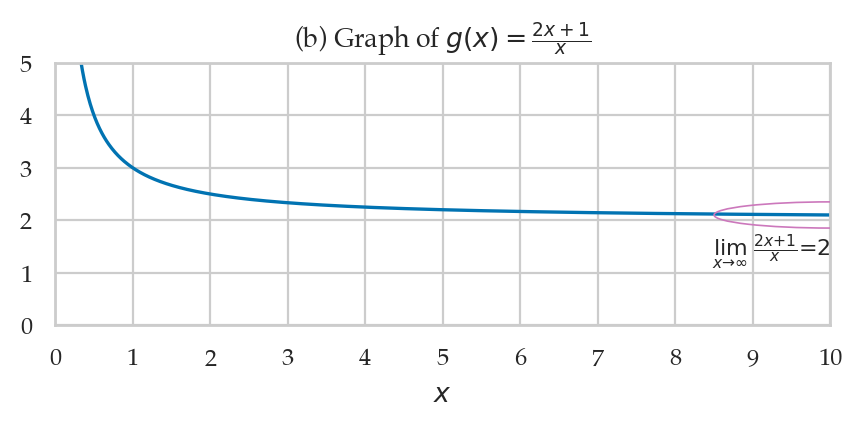

In [49]:
# Define the function  g(x) = (2x+1)/x
def g(x):
    return (2*x+1)/x

ax = plot_limit(g, xlim=[0,10], ylim=[0,5])
ax.set_xticks(range(0,11))
ax.set_xlabel("$x$")
ax.set_title("(b) Graph of $g(x) = \\frac{2x+1}{x}$")

# Ellipse annotation at x \to \infty
plot_ellipse(ax, 10, 2.1, 3, 0.5, lx=10, ly=1.4, ha="right",
             label=r"$\lim_{x \to \infty}\; \frac{2x+1}{x} = 2$");

### Limits at a point

We can use limit expressions to describe what happens
when a function approaches some number $x=a$.
The limit expression $\lim_{x \to a^+} f(x)$
describes the behaviour of the function $f(x)$
as $x$ approaches $a$ *from the right*.
To compute this limit,
we imagine a small distance $\delta$ (the Greek letter *delta*)
that that gets smaller and smaller,
and compute the following equivalent limit expression
$$
    \lim_{x\to a^+} f(x) = \lim_{\delta \to 0} f(a + \delta).
$$

This limit expression describes the value of the function $f$
for inputs like $a+0.1$, $a+0.01$, $a+0.001$, $a+0.0001$, etc.
In other words,
the input $x$ gets closer and closer to $a$ (from the right)
without ever touching $x=a$.

#### Example

Consider the function $f(x) = \frac{1}{x}$ again.
The limit $\lim_{x \to 0^+} f(x)$,
read "the limit of $f(x)$ as $x$ goes to zero,"
asks us to evaluate the function $f$ for inputs like
$x=0.1$, $x=0.01$, $x=0.001$, $x=0.0001$, etc.
The outputs of $f(x) =~\frac{1}{x}$ get larger and larger
as $x$ takes on smaller and smaller values,
so the limit goes to infinity:
$$\lim_{x\to 0^+} \tfrac{1}{x}
    = \lim_{\delta \to 0} \tfrac{1}{0^+\delta}
    = \lim_{\delta \to 0} \tfrac{1}{\delta} = \infty.$$

In words,
the function $f(x) = \frac{1}{x}$ "blows up" to infinity as $x$ goes to $0^+$,
as shown below.

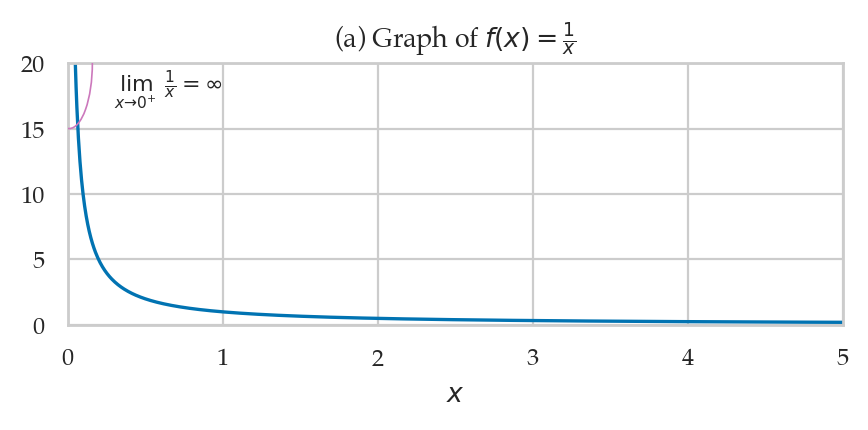

In [50]:
ax = plot_limit(finv, xlim=[0,5], ylim=[0,20])
ax.set_xticks([0,1,2,3,4,5])
ax.set_xlabel("$x$")
ax.set_title(r"(a) Graph of $f(x) = \frac{1}{x}$")

# ellipse annotation x \to 0+
plot_ellipse(ax, 0.01, 20, 0.3, 10, lx=0.3, ly=18, 
             label=r"$\lim_{x \to 0^+}\; \frac{1}{x} = \infty$");

The limit of $f(x)$ when $x$ approaches $a$ *from the left*
is defined analogously,
$\lim_{x\to a^-} f(x)  = \lim_{\delta \to 0} f(a - \delta)$.
If both limits from the left and from the right at $x=a$
exist and are equal to each other,
we can drop the $^+$ and $^-$ annotations,
and talk about the limit $x\to a$:
$$
    \lim_{x\to a} f(x) =  \lim_{x\to a^+} f(x) =  \lim_{x\to a^-} f(x).
$$

For the two-sided limit of a function to exist at a point,
both the limit from the left and the limit from the right must converge to the same number.

### Continuity

If the function $f(x)$ obeys,
$f(a) = \lim_{x\to a} f(x)$,
we say the function $f(x)$ is *continuous* at $x=a$.
Geometrically,
the graph of the continuous function at $x=a$ is a smooth curve
that doesn't have a hole or a jump at $x=a$.

#### Example 5

Is the function $g(x)=\frac{2x+1}{x}$ continuous at $x=1$?
First,
we evaluate the function $g(x)$ for the input $x=1$,
which gives us $g(1) = \frac{2(1)+1}{1} = \frac{3}{1}=3$.
Next we compute the limit from the right at $x=1$
which is:
$$
    \lim_{x\to 1^+}\! g(x)
        = \!\!\lim_{x\to 1^+}\!\! \tfrac{2x+1}{x}
        = \lim_{\delta \to 0}\! \tfrac{2(1+\delta)+1}{1+\delta}
        = \lim_{\delta \to 0}\! \tfrac{2+2\delta+1}{1+\delta}
        = \tfrac{3}{1}
        = 3.
$$

The $\delta$ terms in the numerator and denominator go to zero.
We evaluate the limit from the left using similar steps:
$$
\lim_{x\to 1^-} g(x) = \lim_{x\to 1^-} \frac{2x+1}{x} = \lim_{\delta \to 0} \tfrac{2(1-\delta)+1}{1-\delta} = 3.
$$

Since the limits from the left and the right are equal,
$\lim_{x\to 1^+} g(x) = \lim_{x\to 1^-} g(x)$,
we say that the two-sided limit exists $\lim_{x\to 1} g(x) = 3$.
Since $\lim_{x\to 1} g(x) = g(3)$,
the function $g(x)$ is continuous at $x=1$.



### Computing limits using SymPy

In [51]:
import sympy as sp

#### Arithmetic operations with infinity

Infinity $\infty$ is denoted `sp.oo` (two lowercase `o`s) in SymPy.
Infinity is not a number but a process: the process of counting forever.
When we use $\infty$ in math expressions and comparisons,
we lead to some surprising facts,
which we can illustrate using SymPy.

Adding a number to infinity still produces infinity,
$\infty + 1 = \infty$.

In [52]:
sp.oo + 1

Infinity is greater than any finite number:

In [53]:
5000 < sp.oo

A number divided by infinity is zero, $1/\infty = 0$:

In [54]:
1 / sp.oo

#### Example 1 using SymPy

We can use SymPy to calculate the limit as $n$ goes to infinity:

In [55]:
import sympy as sp
n, r = sp.symbols("n r")
A_n = n * r**2 * sp.cos(sp.pi/n) * sp.sin(sp.pi/n)
sp.limit(A_n, n, sp.oo)

We see the result of the limit is $\pi r^2$,
which is the formula for the area of a circle
we were looking for.

#### Example 2 using SymPy

The number $e$ is defined as the limit $\lim_{n\to\infty}\left(1+\frac{1}{n}\right)^n$:

In [56]:
n = sp.symbols("n") 
sp.limit((1+1/n)**n, n, sp.oo)

In [57]:
sp.limit((1+1/n)**n, n, sp.oo).evalf(40)

This limit expression describes the annual growth rate of a loan with
a nominal interest rate of 100\% and infinitely frequent compounding.
Borrow $\$1000$ in such a scheme, and you'll owe $\$2718.28$ after one year.

#### Example 3 using SymPy

In [58]:
x = sp.symbols("x")
sp.limit(1/x, x, sp.oo)

To evaluate the limit from the right or the left at a point,
we must provide a fourth argument,
either `"+"` or `"-"`,
when calling the function `sp.limit`.

In [59]:
sp.limit(1/x, x, 0, "+")

In [60]:
sp.limit(1/x, x, 0, "-")

#### Example 4 using SymPy

Let's check the result $\lim_{x\to \infty}\!\! \tfrac{2x+1}{x} = 2$.

In [61]:
sp.limit((2*x+1)/x, x, sp.oo)

#### Example 5 using SymPy

Is the function $g(x) = \frac{2x+1}{x}$ continuous at $x=1$?

In [62]:
# The limit of g(x) at x=1 from the left
sp.limit((2*x+1)/x, x, 1, "-")

In [63]:
# Evaluate g(x) at x=1
((2*x+1)/x).subs({x:1})

In [64]:
# The limit of g(x) at x=1 from the right
sp.limit((2*x+1)/x, x, 1, "+")

The fact that all three expressions exist and
are equal to each other,
$$
    \lim_{x \to 1^-} g(x) = g(1) = \lim_{x \to 1^+} g(x),
$$
tells us that the function $g(x)=\frac{2x+1}{x}$ is continuous at $x=1$.
Intuitively,
you can understand continuity by imagining a pen drawing the graph at $x=1$.
Th pen comes in from the left at height $\lim_{x\to 1^-} g(x) =~3$,
goes through $g(1) = 3$,
then leaves to the right at the same height $\lim_{x\to 1^+} g(x) = 3$.

### Applications of limits

#### Limits for derivatives

The formal definition of a function's derivative is expressed in terms
of the rise-over-run formula for an infinitely short run:

$$f^{\prime\!}(x) 
  =  \lim_{\textrm{run} \to 0} \frac{\text{rise}}{\text{run}} 
  =  \lim_{\delta \to 0} \frac{f(x+\delta)\; - \; f(x)}{x+\delta \; - \;  x}
  =  \lim_{\delta \to 0} \frac{f(x+\delta)\; - \; f(x)}{\delta}.
$$

More on derivatives in the next section.

#### Limit for integrals

One way to approximate the area under the graph of the function $f(x)$
between $x=a$ and $x=b$ is to split the area into $n$ rectangular strips
of width $\Delta x = \frac{b-a}{n}$ and height $f(x)$, and then
calculate the sum of the areas of these rectangles:

$$A_f(a,b) \approx \underbrace{
                            \Delta x f(a+\Delta x)
                            \!+\! \Delta x f(a+2\Delta x) 
                            % \!+\! \Delta x f(a+2\Delta x) + \cdots 
                            \!+\! \Delta x f(b)
                        }_{n \textrm{ terms}}.$$
                        
We obtain the exact
value of the area in the limit where we split the area into an infinite
number of rectangles with infinitely narrow width:

$$A_f(a,b) = \!\!\int_a^b\!\!\!f(x) \, dx
           = \!\!\lim_{n \to \infty} \Delta x \left[ 
             f(a+\Delta x) \!+\! f(a+2\Delta x) \!+\! \cdots \!+\!  f(b) 
            \right].$$

#### Limits for series

We use limits to describe the convergence properties of series. For
example, the sum of the first $n$ terms of the geometric series
$r^k$ corresponds to the following expression:

$$\sum_{k=0}^n r^k
               = 1 + r + r^2 + r^3 + \cdots + r^n
               = \frac{1-r^{n+1}}{1-r}.$$

The *series* $\sum r^k$
is defined as the limit $n\to \infty$ of the above
expression.
When $|r|<1$,
the geometric series *converges* to the a finite value:

$$\lim_{n \to \infty} \sum_{k=0}^n r^k
                = 1 + r + r^2 +  r^3 + \cdots 
                = \frac{1}{1-r}.$$


In each of these domains,
limit expressions will help us make precise statements
that describe calculus procedures
with infinite small lengths and an infinite number of steps.

## Derivatives

The derivative function, denoted $f'(x)$, $\frac{d}{dx}\big[f(x)\big]$, $\frac{df}{dx}$, or $\frac{dy}{dx}$, 
describes the instantaneous *rate of change* of the function $f(x)$.
Geometrically,
the derivative $f'(x)$ tells us the *slope* of the function $f$ at $x$.

Let's start by looking at the average slope calculation
between two points separated by the distance $\Delta x$,
which is read "delta x."

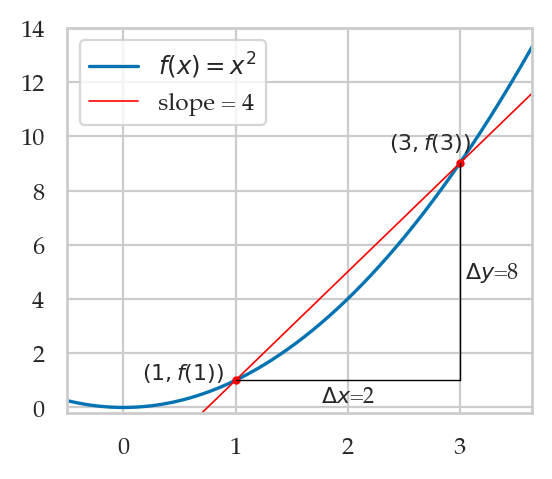

In [65]:
from ministats.calculus import plot_slope

def f(x):
    return x**2

step = 2  # CHANGE ME
with plt.rc_context({"figure.figsize": (3,2.5)}):
    ax = plot_slope(f, x=1, delta=step, xlim=[-0.5,3.65], ylim=[-0.2, 12])
    ax.set_xticks(range(0,4))
    ax.set_yticks(range(0,16,2))

The average slope is calculated using the formula
$\text{slope} = \frac{\Delta y}{\Delta x}$,
where $\Delta x =$ `step` is the length of the horizontal step,
and $\Delta y$ is the change in the function's output,
$\Delta y = f(x+\Delta x) - f(x)$.

Try changing the value of the variable `step` and rerun the above code.
What happens when yo use a very small steps like $0.1$, $0.01$, and $0.001$?

### Derivative formula

The derivative function $f^{\prime\!}(x)$ is defined as the following limit:
$$
    f^{\prime\!}(x)
        \;\;= \;\; 
        \lim_{\delta \to 0} \frac{f(x+\delta)\ - \ f(x)}{\delta}\,.
$$
Here $\delta$ plays the same role as $\Delta x$,
but we let $\delta$ go to zero.

### Numerical derivative calculations

The derivative is the slope calculation
for a very very short step,
which we'll denote `delta` to match the math definition.

In [66]:
def differentiate(f, x, delta=1e-9):
    """
    Compute the derivative of the function `f` at `x` using
    the slope calculation with a very short step `delta`.
    """
    df = f(x+delta) - f(x)
    dx = (x + delta) - x
    return df / dx

In [67]:
def f(x):
    return x**2

differentiate(f, 1)

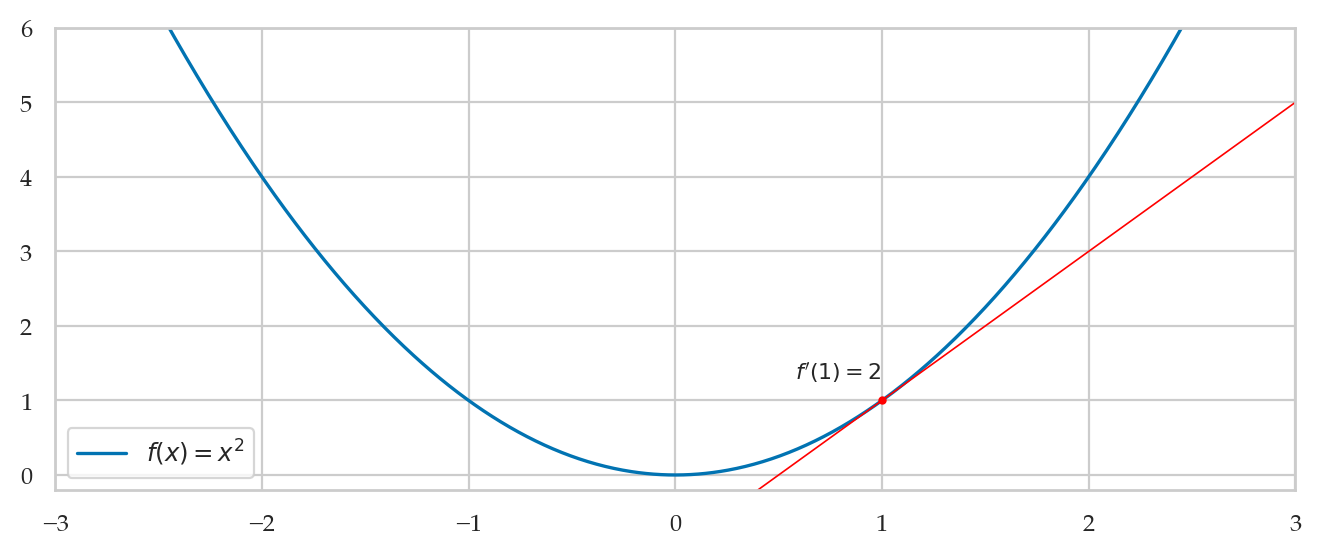

In [68]:
plt.figure(figsize=(8,3))
plot_slope(f, x=1, delta=0, xlim=[-3,3], ylim=[-0.2,6]);

In [69]:
differentiate(f, -0.5)

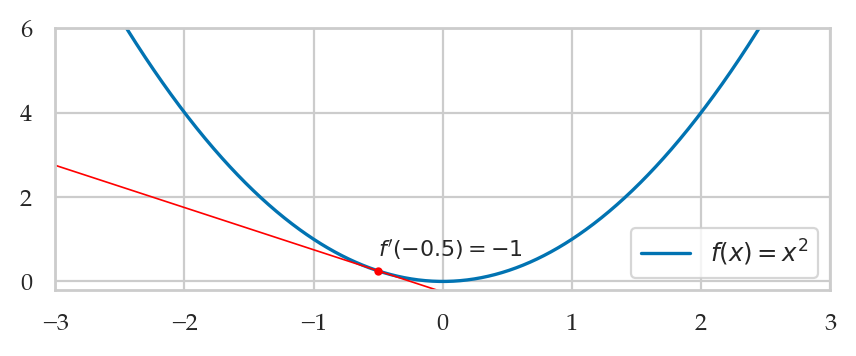

In [70]:
plot_slope(f, x=-0.5, delta=0, xlim=[-3,3], ylim=[-0.2,6]);

<a name="derivative_formulas"></a>
### Derivative formulas

\begin{align*}
f(x)					&  \ -\textrm{derivative}\to  \   				f^{\prime\!}(x)	\\
a					&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		0			\\
x					&\qquad  - \tfrac{d}{dx} \rightarrow \qquad		1			\\
mx+b				&\qquad  - \tfrac{d}{dx} \rightarrow \qquad		m			\\
x^n, \text{ for } n\neq 0	&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		nx^{n-1}		\\
\tfrac{1}{x} =  x^{-1}		&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		\tfrac{-1}{x^2} = -x^{-2}	\\
\sqrt{x} = x^{\frac{1}{2}}	&\qquad  - \tfrac{d}{dx} \rightarrow \qquad		\tfrac{1}{2\sqrt{x}} = \tfrac{1}{2}x^{-\frac{1}{2}} \\
e^x					&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		e^x			\\
\ln(x)					&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		\tfrac{1}{x}		\\
\sin(x)				&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		\cos(x)		\\
\cos(x)				&\qquad  - \tfrac{d}{dx} \rightarrow \qquad 		-\sin(x)
\end{align*}

### Derivative rules

In addition to the table of derivative formulas, there are some
important derivatives rules that allow you to find derivatives of
*composite* functions.

#### Constant multiple rule

The derivative of $k$ times the function $f(x)$ is equal to $k$ times
the derivative of $f(x)$:

$$\big[ k f(x) \big]^\prime       =   k f^{\prime\!}(x).$$

#### Sum rule

The derivative of the sum of two functions is the sum of their
derivatives:

$$\big[ f(x) +  g(x) \big]^\prime =   f^{\prime\!}(x) + g^{\prime\!}(x).$$

#### Product rule

The derivative of a product of two functions is the sum of two
contributions:

$$\big[ f(x)g(x) \big]^\prime         =   f^{\prime\!}(x)g(x)  + f(x)g^{\prime\!}(x).$$

In each term, the derivative of one of the functions is multiplied by
the value of the other function.

#### Quotient rule

This formula tells us how to obtain the derivative of a fraction of two
functions:

$$\left[ \frac{f(x)}{g(x)} \right]^\prime =   \frac{f^{\prime\!}(x)g(x)-f(x)g^{\prime\!}(x)}{g(x)^2}.$$

#### Chain rule

If you encounter a situation that includes an inner function and an
outer function, like $f(g(x))$, you can obtain the derivative by a
two-step process:

$$\big[ f(g(x)) \big]^\prime  =   f^{\prime\!}(g(x))g^{\prime\!}(x).$$

In the first step, we leave the inner function $g(x)$ alone and focus on
taking the derivative of the outer function $f(x)$. This step gives us
$f^{\prime\!}(g(x))$, which is the value of $f^{\prime}$ evaluated at
$g(x)$. In the second step, we multiply this expression by the
derivative of the *inner* function $g^{\prime\!}(x)$.


### Higher derivatives

The second derivative of $f(x)$ is denoted $f^{\prime\prime\!}(x)$ or
$\frac{d^2f}{dx^2}$. It is obtained by applying the derivative operation
to $f(x)$ *twice*: $\frac{d}{dx}\big[ \frac{d}{dx}[\texttt{<f>}]\big]$.

Geometrically, the second derivative $f^{\prime\prime\!}(x)$ tells us
the *curvature* of $f(x)$. Positive curvature means the function opens
upward and looks like the bottom of a valley. The function $f(x)=x^2$
has derivative $f^{\prime\!}(x) = 2x$ and second derivative
$f^{\prime\prime\!}(x) = 2$, which means it has positive curvature everywhere.
Negative curvature means the function opens downward and looks like a
mountain peak. For example, the function $g(x) = -x^2$ has negative
curvature, since its second derivative is $g^{\prime\prime\!}(x) = -2 < 0$.

### Examples

We'll use the SymPy function `sp.diff` to computes the derivative in the following examples.

#### Example 6

Calculate the derivative of $f(x) = e^{x^2}$.

In [71]:
x = sp.symbols("x")
sp.diff(sp.exp(x**2), x)

#### Example 7

To find the derivative of $f(x) = \sin(x)e^{x^2}$.

In [72]:
sp.diff(sp.sin(x)*sp.exp(x**2), x)

#### Example 8

Calculate the derivative of $\sin(x^2)$.

In [73]:
sp.diff(sp.sin(x**2), x)

### Checking the derivative formulas using SymPy

The [table of derivative formulas](#derivative_formulas) 
tells us that $\big[mx+b\big]^\prime = m$.
Let's verify that SymPy gives the same answer.

In [74]:
m, x, b = sp.symbols("m x b")
sp.diff(m*x + b, x)

We can also verify the derivative formula
for the polynomial term $\big[x^n\big]^\prime = nx^{n-1}$.

In [75]:
x, n = sp.symbols("x n")
sp.simplify(sp.diff(x**n, x))

The exponential function $f(x)=e^x$
is an interesting special case,
because it is equal to its derivative:

In [76]:
from sympy import exp
sp.diff(exp(x), x)

Here is a mix of three other functions 
from the [table of derivative formulas](#derivative_formulas).

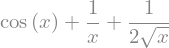

In [77]:
from sympy import sqrt, sin, ln
sp.diff(sin(x) + ln(x) + sqrt(x), x)

### Applications of derivatives

#### Tangent lines

The *tangent line* to the function $f(x)$ at $x=x_0$ is 
the line that passes through the point $(x_0, f(x_0))$ and has 
the same slope as the function at that point.
The tangent line to the function $f(x)$ at the point $x=x_0$ is described by the following formula:
$$
   T_1(x) =  f(x_0) \ + \  f'(x_0)(x-x_0).
$$

Let's find the equation of the tangent line to $f(x)=x^2$ at $x_0=1$?

In [78]:
fs = x**2
fs

In [79]:
dfsdx = sp.diff(fs, x)
dfsdx

In [80]:
x0 = 1
T_1 = fs.subs({x:x0}) + dfsdx.subs({x:x0})*(x - x0)
T_1

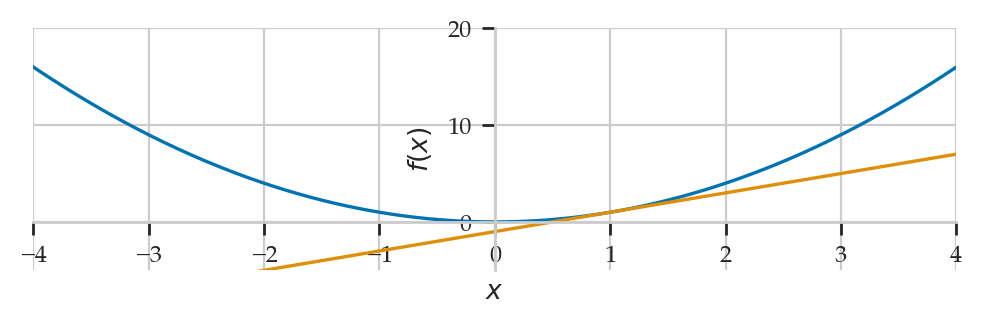

In [81]:
# Plot the function `f` and the tangent line `T_1`
sp.plot(fs, 2*x-1, xlim=[-4,4], ylim=[-5,20]);

We can see that the tangent line $T_1(x) = 2x -1$
pass through the point $(1,1)$
and has same slope as $f(x)$ at $x=1$.

### Solving optimization problems using derivatives

Optimization is all finding the input for a function $f(x)$ that results in the best value for $f(x)$.
The best value could be a *maximum* value
(when the function represents something desirable like profits) 
or a *minimum* value 
(when the function represents something undesirable like costs).

The derivative $f'(x)$ encodes the information about the *slope* of $f(x)$.
Positive slope $f'(x)>0$ means $f(x)$ is increasing,
negative slope $f'(x)<0$ means $f(x)$ is decreasing, 
and zero slope $f'(x)=0$ means the graph of the function is horizontal.
The *critical points* of a function $f(x)$ are the solutions to the equation $f'(x)=0$.
Each critical point is a candidate to be either a maximum or a minimum of the function.

<!-- 
The second derivative $f^{\prime\prime}(x)$ encodes the information about the *curvature* of $f(x)$.
Positive curvature means the function looks like $x^2$,
negative curvature means the function looks like $-x^2$. -->

#### Analytical optimization using SymPy

#### Example 9

We define the SymPy expression `qx`
that corresponds function $q(x) = (x-5)^2$
and look at its graph.

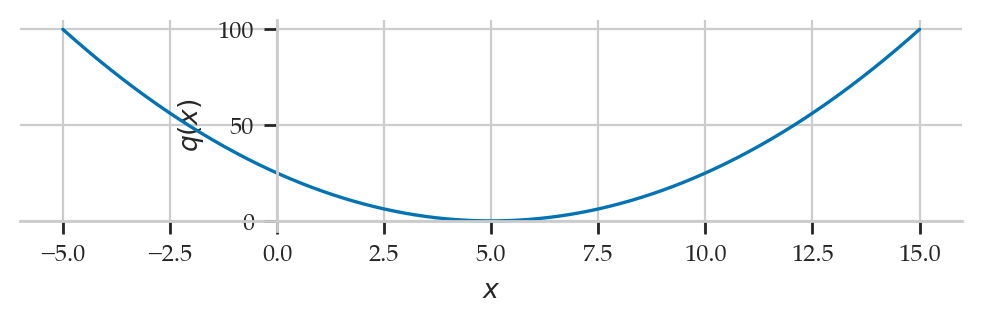

In [82]:
x = sp.symbols('x')
qx = (x - 5)**2
sp.plot(qx, (x,-5,15), ylabel="$q(x)$");

Next,
we find the critical point(s)
by solving the equation $q'(x) = 0$.

In [83]:
sols = sp.solve(sp.diff(qx,x), x)
sols  # = list of critical points

We see the function has only a single critical point $x^*_1 = 5$.
Let's check the sign of the second derivative at $x^*_1 = 5$.

In [84]:
sp.diff(qx, x, 2).subs({x:sols[0]})

The second derivative is positive (like the bottom of a valley),
so this means $x^*_1 = 5$ is a minimum.

#### Example 10

Let's find the critical points of the function $r(x)=x^3-2x^2+x$ 
and use the information from its second derivative 
to find where the function reaches its maximum value
between $x=0$ and $x=1$.

In [85]:
x = sp.symbols('x')
rx = x**3 - 2*x**2 + x

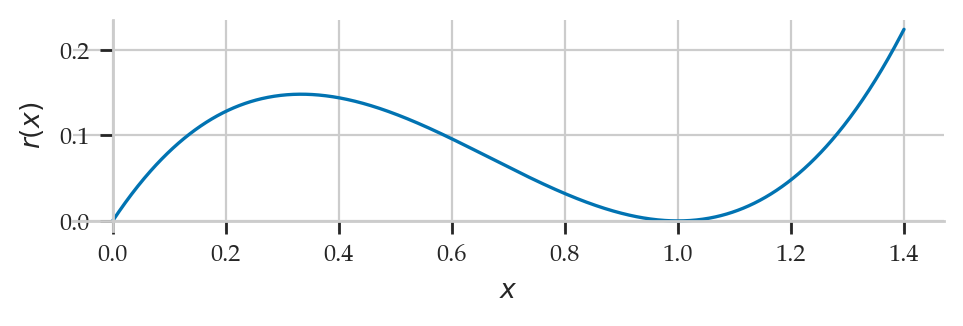

In [86]:
sp.plot(rx, (x,0,1.4), ylabel="$r(x)$");

Next,
we compute the derivative $r'(x)$
and call the SymPy method `.factor()`
to simulate what we would have to do on paper
to find the critical values.

In [87]:
sp.diff(rx, x).factor()

We see the critical points are $x^*_1 = \frac{1}{3}$ and $x^*_2 = 1$.
We can confirm this more directly by asking SymPy
to solve the equation $r'(x)=0$.

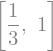

In [88]:
sols = sp.solve(sp.diff(rx,x),  x)
sols  # list of critical points

We want to now check if 
the critical values $x^*_1 = \frac{1}{3}$
and $x^*_2 = 1$ are minimum or maximum
by computing the second derivative of $r(x)$.

In [89]:
sp.diff(rx, x, 2)

We now evaluate $r''(x)$ at $x^*_1 = \frac{1}{3}$.

In [90]:
sp.diff(rx, x, 2).subs({x:sols[0]})

The critical point $x^*_1=\frac{1}{3}$
is a local maximum because it is a critical point of $r(x)$
where the curvature is negative,
meaning $r(x)$ looks like the peak of a mountain at $x^*_1=\frac{1}{3}$.

We also evaluate $r''(x)$ at $x^*_2 = 1$.

In [91]:
sp.diff(rx, x, 2).subs({x:sols[1]})

The critical point $x^*_2=1$ is a local minimum because the function has positive curvature at $x^*_2=1$.
This means $r(x)$ looks like the bottom of a valley at $x^*_2=1$.
We can confirm this by looking at the graph of the function.

#### Numerical optimization

If we repeatedly take steps in the "downhill" direction,
we'll end up at the bottom of a valley.
This is the idea behind the *gradient descent algorithm*.

In [92]:
def gradient_descent(f, x0=0, alpha=0.01, tol=1e-10):
    """
    Find the minimum of the function `f` using gradient descent.
    """
    current_x = x0
    change = 1
    while change > tol:
        df_at_x = differentiate(f, current_x)
        next_x = current_x - alpha * df_at_x
        change = abs(next_x - current_x)
        current_x = next_x
    return current_x

#### Example 9 revisited

In [93]:
def q(x):
    return (x - 5)**2

gradient_descent(q, x0=10)

#### Example 10 revisited

In [94]:
def r(x):
    return x**3 - 2*x**2 + x

gradient_descent(r, x0=10)

#### Numerical optimization using SciPy

Let's now solve the optimization problems from examples 9 and 10 using the function `minimize` from `scipy.optimize`.

In [95]:
from scipy.optimize import minimize

minimize(q, x0=10)["x"][0]

In [96]:
minimize(r, x0=10)["x"][0]

## Integrals

### Act 1: Integrals as area calculations

The *integral* of $f(x)$ corresponds to the computation of the area under the graph of $f(x)$.
The area under $f(x)$ between the points $x=a$ and $x=b$ is computed using the following integral:

$$
 A_f(a,b) = \int_a^b f(x) \: dx.
$$

The numbers $a$ and $b$ are called the *limits of integration*.

![](./attachments/calculus/integral_as_region_under_curve_Aab.png)


The integral of the function $f(x)$ between $x=a$ and $x=b$
corresponds to the area of the shaded region in the above figure.

### Properties of integrals

The following properties of integrals follow from their interpretation as area calculations.

-   The sum of the integral from $a$ to $b$
    and the integral from $b$ to $c$
    is equal to the integral starting from $a$ going all the way to $c$:
    $\int_a^b f(x) \, dx + \int_b^c f(x) \, dx = \int_a^c f(x) \, dx$.

-   The integral of $k$ times the function $f(x)$
    is equal to $k$ times the integral of $f(x)$:
    $\int_a^b kf(x)\, dx = k\int_a^b f(x)\, dx$.

-   The integral of the sum of two functions
    is the sum of their integrals:
    $\int_a^b [f(x) + g(x)]\, dx = \int_a^b f(x)\, dx +  \int_a^b g(x)\, dx$.

-   An integral over a region with zero width has zero value:
    $\int_a^a f(x)\, dx = 0$.
    Geometrically,
    this integral defines a region with height $f(x)$ and width $0$,
    so it has zero area.


#### Example 11: integral of a constant function

The figure below
illustrates the integral under $f(x) = 3$ between $a=0$ and $b=5$,
which we denote $\int_0^5 f(x)\,dx$.

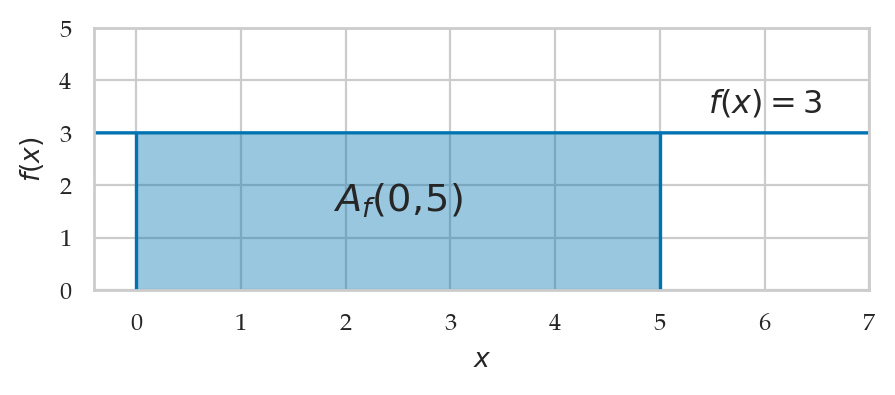

In [97]:
from ministats.calculus import plot_integral

def f(x):
    return 3
    
ax = plot_integral(f, a=0, b=5, xlim=[-0.4,7], flabel="f")
ax.set_ylim([0,5])
ax.text(6, 3.4, "$f(x)=3$", ha="center", fontsize="large")
ax.text(2.5, 1.5, "$A_f(0,\\!5)$", ha="center", fontsize="x-large");

The area under $f(x)$ between $x=0$ and $x=5$
is described by the following integral calculation:

$$A_f(0,5)
    = \int_0^5 f(x)\,dx
    = 3\cdot 5
    = 15.$$

The area under the graph of $f(x)$ is a rectangle with height $3$ and width $5$,
so its area is $3 \cdot 5 = 15$.

#### Example 12: integral of a linear function

Let's now visualize the integral under $g(x) = x$ between $a=0$ and $b=5$,
which we denote $\int_0^5 g(x)\,dx$.

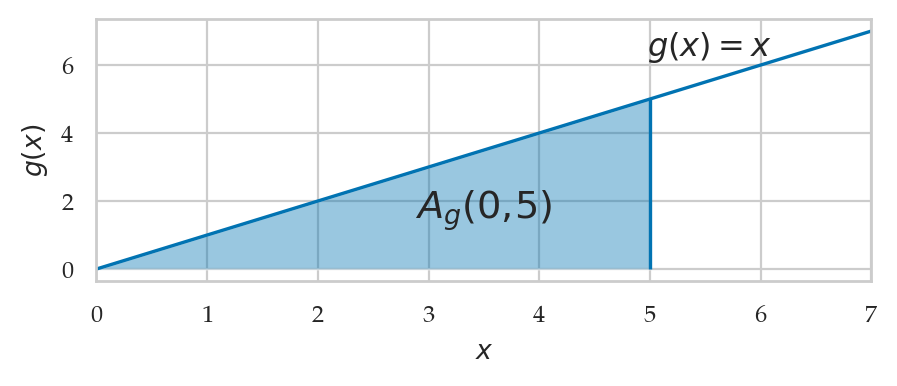

In [98]:
def g(x):
    return x

ax = plot_integral(g, a=0, b=5, xlim=[0,7], flabel="g")
ax.text(6.1, 6.3, "$g(x)=x$", ha="right", fontsize="large")
ax.text(3.5, 1.5, "$A_g(0,\\!5)$", ha="center", fontsize="x-large");

This area is described by the following integral calculation:
$$A_g(0,5)
    = \int_0^5 g(x) \, dx
    = \tfrac{1}{2} 5 \cdot 5
    = \tfrac{1}{2}5^2
    = \tfrac{25}{2}
    = 12.5.$$
The region under the graph of $g(x)$ has a triangular shape,
so we can compute its area using the formula for the area of a triangle:
base times height divided by 2.

#### Example 13: integral of a polynomial

Consider now the function $h(x) = 4 - x^2$.
We want to know the area under the graph of $h(x)$
between $x=0$ and $x=2$,
which is described by the following integral:
$$A_h(0,2)
                    = \int_{0}^2 h(x)\,dx \,
                    = \; ???.$$

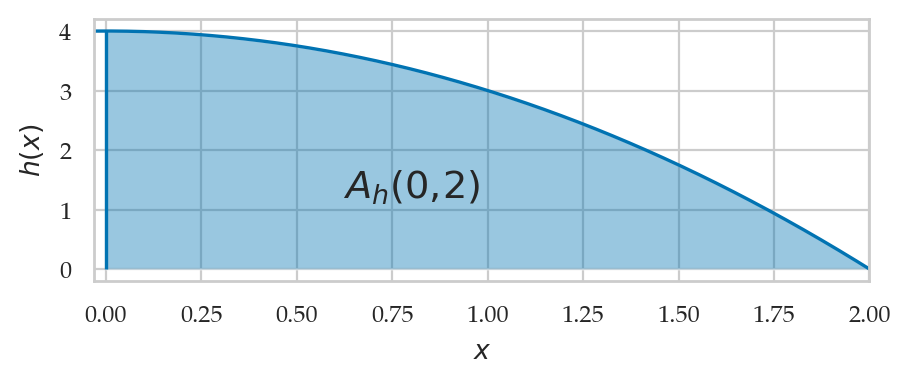

In [99]:
def h(x):
    return 4 - x**2

ax = plot_integral(h, a=0, b=2, xlim=[-0.03,2], flabel="h")
ax.text(0.8, 1.2, "$A_h(0,\\!2)$", ha="center", fontsize="x-large");

The region under the graph of $h(x)$ is curved
and not a simple recognizable geometric shape with a known area formula.
How could we compute the integral $\int_{0}^2 h(x)\,dx$ in this case?

### Computing integrals numerically

Computing the integral of $f(x)$ numerically means
we're splitting the region of integration into many (think thousands or millions) of rectangular strips,
computing the areas of these strips,
then adding up the areas to obtain the total area under the graph of $f(x)$.
The approximation to the area under $f(x)$ between $x=a$ and $x=b$
using $n$ rectangular strips corresponds to the following formula:

$$
    A_f(a,b)
    \approx
    \sum_{k=1}^{n} f(a + k\Delta x)\,\Delta x,
$$

where $\Delta x = \frac{b-a}{n}$ is the width of each rectangular strip.
The right endpoint of the $k$th
is located at $x_k = a + k\Delta x$,
so the height of the rectangular strips $f(x_k)$
varies as $k$ goes from $k=1$ (first strip)
to $k=n$ (last strip).

This is known as the *Riemann sum* formula for approximating areas.
We'll can turn the Riemann sum formula into a Python procedure
that performs the $n$-rectangle area calculation:

In [100]:
def integrate(f, a, b, n=10000):
    """
    Computes the area under the graph of `f`
    between `x=a` and `x=b` using `n` rectangles.
    """
    dx = (b - a) / n                       # width of rectangular strips
    xs = [a + k*dx for k in range(1,n+1)]  # right-corners of the strips
    fxs = [f(x) for x in xs]               # heights of the strips
    area = sum([fx*dx for fx in fxs])      # total area
    return area

#### Example 13 continued

Let's use the `integrate` procedure
to compute the integral of the function $h(x) = 4- x^2$.

In [101]:
def h(x):
    return 4 - x**2

Let's start with $n=10$,
which is a very rough approximation.

In [102]:
integrate(h, a=0, b=2, n=10)

Riemann sum with n=10 rectangles: approx. area ≈ 4.92000


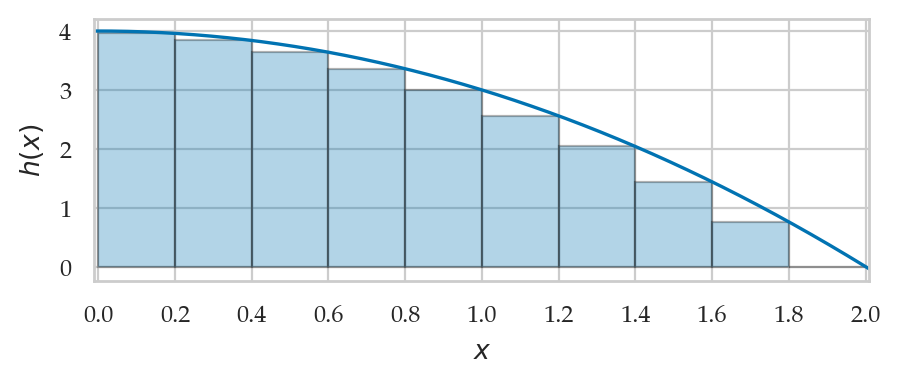

In [103]:
from ministats.calculus import plot_riemann_sum

ax = plot_riemann_sum(h, a=0, b=2, xlim=[-0.01,2.01], n=10, flabel="h")
ax.set_xticks(np.arange(0,2.2,0.2));

We can compute the approximation with $n=20$ rectangles just as easily:

In [104]:
integrate(h, a=0, b=2, n=20)

Riemann sum with n=20 rectangles: approx. area ≈ 5.13000


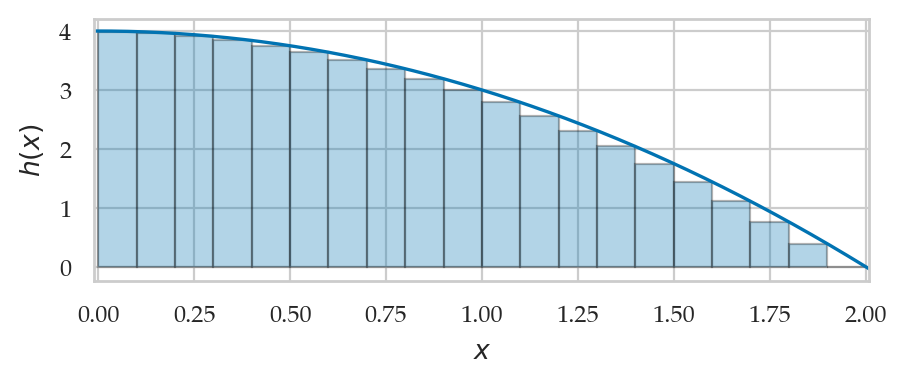

In [105]:
plot_riemann_sum(h, a=0, b=2, xlim=[-0.01,2.01], n=20, flabel="h");

The approximations get better and better
as we increase the number of rectangles $n$.

In [106]:
integrate(h, a=0, b=2, n=50)

In [107]:
integrate(h, a=0, b=2, n=100)

In [108]:
integrate(h, a=0, b=2, n=1000)

In [109]:
integrate(h, a=0, b=2, n=10000)

In [110]:
integrate(h, a=0, b=2, n=1_000_000)

#### Example 11N

We can also use `integrate` to compute the integral of the constant function $f(x)=3$
that we computed geometrically earlier.

In [111]:
def f(x):
    return 3

integrate(f, a=0, b=5, n=100000)

The numerical approximations we obtain is equal to
to the exact answers $\int_0^5 f(x)\,dx = 15$ we obtained earlier
using geometry.

#### Example 12N

Let's now use `integrate` to compute the integral of the linear function $g(x)=x$.

In [112]:
def g(x):
    return x

integrate(g, a=0, b=5, n=100000)

The numerical approximation is close
to the exact answers $\int_0^5 g(x) \, dx = 12.5$.

### Formal definition of the integral

In the limit as the number of rectangles $n$ approaches $\infty$,
the approximation to the area under the graph of $f(x)$
becomes *arbitrarily close* to the true area.

The integral between $x=a$ and $x=b$ is *defined*
as the limit as $n$ goes to infinity of the Riemann sum:
$$\int_{a}^{b}\!f(x)\,dx 
                = \lim_{n\to\infty} \sum_{k=1}^{n} f(a + k\Delta x)\Delta x,
                \quad
                \text{where } \Delta x=\tfrac{b-a}{n}.$$

In words,
the integral is a Riemann sum
that consists of infinitely thin rectangular strips.

### Act 2: Integrals as functions

The *integral function* $F_0$ corresponds to the area calculation as a function 
of the upper limit of integration:

$$
  F_0(b) = \int_0^b \! f(x)\,dx\,.
$$

The area under $f(x)$ between $x=a$ and $x=b$ can be obtained by 
calculating the *change* in the integral function:

$$
   A_f(a,b) = \int_a^b \! f(x)\,dx  =  F_0(b)-F_0(a).
$$

In `SymPy` we use `sp.integrate(f,x)` to obtain the integral function $F_0(x)$ of any function $f(x)$:
$F_0(x) = \int_0^x f(u)\,du$.

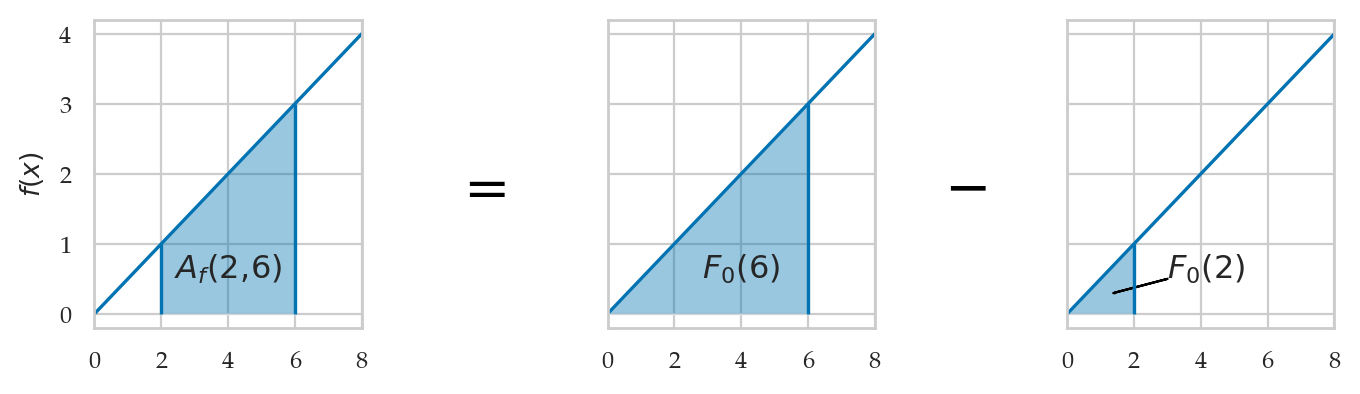

In [113]:
from ministats.book.figures import integral_as_difference_in_G

integral_as_difference_in_G(flabel="f");

#### Example 11 revisited

Here is an illustration of the integral function $F_0$.

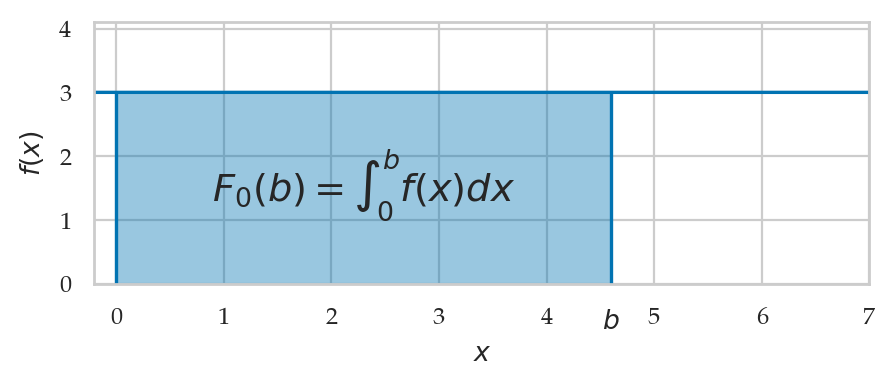

In [114]:
ax = plot_integral(f, a=0, b=4.6, xlim=[-0.2,7], flabel="f")
ax.set_ylim(0,4.1)
ax.set_yticks([0,1,2,3,4])
ax.text(2.3, 1.3, "$F_0(b)=\\int_{\\!0}^{\\!b} f(x)dx$", ha="center", fontsize="x-large");
ax.text(4.6, -0.7, "$b$", ha="center");

The integral function $F_0$ corresponds to the area of a rectangle of height $3$ and width $b$:
$$F_0(b) = A_f(0,b) = \int_0^b \! f(x)\,dx    = 3 b.$$

#### Example 12 revisited

Here is an illustration of the integral function $G_0$.

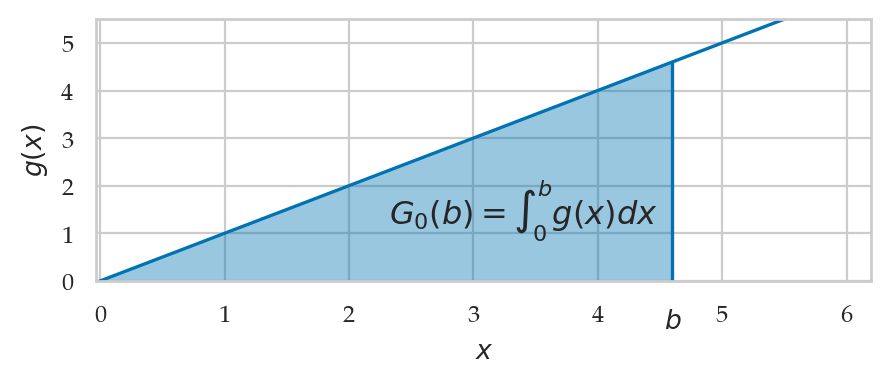

In [115]:
ax = plot_integral(g, a=0, b=4.6, xlim=[-0.03,6.2], flabel="g")
ax.set_ylim(0, 5.5)
ax.set_yticks([0,1,2,3,4,5])
ax.text(3.4, 1.2, "$G_0(b)=\\int_{\\!0}^{\\!b} g(x)dx$", ha="center", fontsize="large");
ax.text(4.6, -1, "$b$", ha="center");

Since the region is triangular,
we can compute its area using the formula for the area of a triangle:
$$G_0(b) = A_g(0,b) = \int_0^b g(x) \, dx = \tfrac{1}{2}b^2.$$

#### Example 13 revisited

Here is an illustration of the integral function $H_0$.

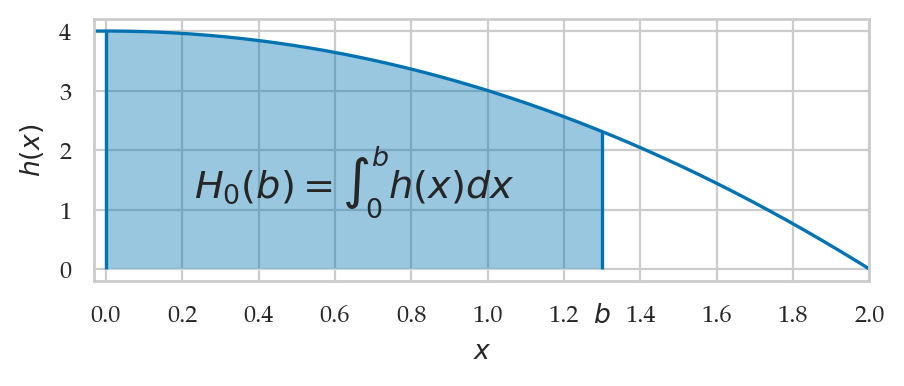

In [116]:
ax = plot_integral(h, a=0, b=1.3, xlim=[-0.03,2], flabel="h")
ax.set_xticks(np.arange(0,2.2,0.2))
ax.text(0.65, 1.2, "$H_0(b)=\\int_{\\!0}^{\\!b} h(x)dx$", ha="center", fontsize="x-large");
ax.text(1.3, -0.9, "$b$", ha="center");

The area under $h(x) = 4 - x^2$ from $x=0$ until $x=b$
is described by the following integral calculation:
$$H_{0}(b) = A_h(0,b) = \int_{0}^b h(x) \, dx = \; ???.$$

We were able to compute the integral functions $F_0(b)$ and $G_0(b)$
thanks to the simple geometries of the areas under the graphs,
but $h(x)$ is a curve so it's not clear how to proceed.
**We require some new integration methods**.

### Act 3: Fundamental theorem of calculus

The integral is the inverse operation of the derivative.
If you perform the integral operation followed by the derivative operation on some function, 
you'll get back the original function:

$$
  \left(\frac{d}{dx} \circ \int dx \right) f(x)
    = \frac{d}{dx} \int_c^x f(u)\,du
    = f(x).
$$

Let's use SymPy to verify that the fundamental theorem of calculus is true
by applying the sequence of operations on the function $\texttt{fx} = f(x) = x^2$.

In [117]:
x = sp.symbols("x")
fx = x**2
Fx = sp.integrate(fx, x)
Fx

In [118]:
sp.diff(Fx, x)

The sequence of operations
$\texttt{sp.diff(sp.integrate(}f(x)\texttt{))} = \frac{d}{dx}\!\int_0^x \!f(u)du$
brings us back to the original `fx` that we started with.

Alternately,
if you compute the derivative of a function $G(x)$ followed by the integral,
you will obtain the original function (up to a constant):

$$
  \left( \int dx \circ \frac{d}{dx}\right) G(x) = \int_c^x G'(u)\,du = G(x) + C.
$$

Let's verify this formula by applying it to the function $\texttt{Gx} = G(x) = x^3$.

In [119]:
Gx = x**3
dGdx = sp.diff(Gx, x)
dGdx

In [120]:
sp.integrate(dGdx, x)

Applying the operations $\texttt{integrate(diff(}G(x)\texttt{))}\!=\int_0^x\!G^{\prime\!}(u)\,du$
brings us back to the original `Gx` that we started with.

#### Using antiderivatives to compute integrals

The fundamental theorem of calculus gives us a symbolic trick for computing
integral function $F_0(b) = \int_0^b f(x)\,dx$.


Given some function $f(x)$,
any function $F(x)$ that satisfies the equation $F^{\prime\!}(x) = f(x)$
is called an *antiderivative* of $f(x)$.
If you can find antiderivative function $F(x)$,
then the integral of $f(x)$ is $F(x)$ plus some constant:

$$
F_0(x) = \int_0^x f(u)\,du = F(x) + C.
$$

To find an antiderivative of $f(x)$,
we look for a function $F(x)$ whose derivative is $f(x)$.
We can use the [table of derivative formulas](#derivative_formulas) in the reverse direction.
For example,
to find the antiderivative of the function $f(x) = m$,
we look for a row where this function appears on the right side of the table,
then look at the corresponding function on the left side of the table,
which is the function $F(x) = mx + b$ in this case.
We can verify that $F^{\prime\!}(x) = f(x)$,
so indeed $F(x) = mx + b$ is an antiderivative of $f(x) = m$.
Furthermore,
the equivalence between antiderivatives and integral functions
tells us that the integral function of $f(x)$ is $F_a(x) = \int_a^x m\,du = mx + b$,
for some constant $b$.

#### Using derivative formulas in reverse

Suppose we want to find the integral of the function
$f(x) = m + e^x + \frac{1}{x} + \cos(x) - \sin(x)$,
which contains a mix of functions from the right side of 
[table of derivative formulas](#derivative_formulas).

In [121]:
fx = m + sp.exp(x) + 1/x + sp.cos(x) - sp.sin(x)
sp.integrate(fx, x)

SymPy tells us the integral function
$F_0$ is $F_0(x) = mx + e^x + \log(x) + \sin(x) + \cos(x)$,
which are all the corresponding terms from the left side of the table of derivative formulas.

### Act 4: Techniques of integration

#### Substitution trick

See the [tutorial PDF](https://minireference.com/static/tutorials/calculus_tutorial.pdf#page=17).


##### Example 14

#### Integration by parts

See the [tutorial PDF](https://minireference.com/static/tutorials/calculus_tutorial.pdf#page=17).

##### Example 15

### Computing integrals numerically using SciPy

We'll now show some examples using the function `quad` form the module `scipy.integrate`.
The function name `quad` is short for quadrature,
which is an old name for computing areas.

#### Example 11N using SciPy

Let's define the function $f(x) = 3$
and compute the integral $\int_0^5 f(x)\,dx$.

In [122]:
from scipy.integrate import quad

def f(x):
    return 3
    
quad(f, 0, 5)

The function `quad` returns two numbers as output:
the value of the integral and a precision parameter.
The output of the above code
tells us the value of the integral is $\int_{0}^5 f(x)\,dx$
is `15.0` and the accuracy of this value up to an error of $1.7\times 10^{-13}$.
Since we're usually only interested in the value of the integral, we often select the first output of `quad` so you'll see the code like `quad(...)[0]` in all the code examples below.

In [123]:
quad(f, 0, 5)[0]

#### Example 12N using SciPy

Define the function $g(x) = x$
and compute the integral $\int_0^5 g(x)\,dx$.

In [124]:
def g(x):
    return x

quad(g, 0, 5)[0]

#### Example 13N using SciPy

Lets now compute $\int_{0}^2 h(x)\,dx$
for the function $h(x) = 4 - x^2$.

In [125]:
def h(x):
    return 4 - x**2

quad(h, 0, 2)[0]

### Computing integral functions symbolically using SymPy

We can use Python to do *symbolic* integration using variables (symbols) instead of numbers.
The SymPy function `sp.integrate` allows us to obtain the formulas for integrals and integral functions.
We'll now revisit the integral calculations from the three examples using symbolic math.
We start by defining three symbols `x`, `a`, and `b`.

In [126]:
import sympy as sp
x, a, b = sp.symbols("x a b")

We'll use these symbols to express the functions and the limits of integration.

#### Example 11S: Constant function

Consider the constant function $f(x) = 3$,
which we can define as follows:

In [127]:
fx = 3
fx

To compute the integral $\int_a^b f(x) dx$,
we call the SymPy function `sp.integrate`,
passing in the function `fx` as the first argument,
and the triple $\texttt{(x,a,b)}$ as the second argument,
which specifies the variable of integration
and the limits of integration $a$ and $b$.

In [128]:
sp.integrate(fx, (x,a,b))  # = A_f(a,b)

The answer $3\cdot (b-a)$ is the general expression for calculating the area under $f(x)=3$,
for between any starting point $x=a$ and end point $x=b$.
Geometrically, this is just a height-times-width formula for the area of a rectangle.

To compute the specific integral between $a=0$ and $b=5$,
we use the `.subs` (substitute) method,
passing in a Python dictionary of the values we want to "plug" into the general expression.

In [129]:
sp.integrate(fx, (x,a,b)).subs({a:0, b:5})

The integral function $F_0(b) = \int_0^b f(x) dx$
is obtained by specifying the variable `b` as the upper limit of integraiotn.

In [130]:
F0b = sp.integrate(fx, (x,0,b))  # = F_0(b)
F0b

We can obtain the area $A_f(0,5)$
by computing the change in integral function $A_f(0,5) = F_0(5) - F_0(0)$.

In [131]:
F0b.subs({b:5}) - F0b.subs({b:0})

#### Example 12S: Linear function

Let's now compute the integral function of the linear function $g(x) = x$,
which corresponds to the following SymPy expression:

In [132]:
gx = x
gx

The integral function $G_0(b) = \int_0^b g(x) dx$
is obtained using a variable as the upper limit of integration.

In [133]:
G0b = sp.integrate(gx, (x,0,b))  # = G_0(b)
G0b

Note this is the same formulas as the formula we obtained using geometry.
We can now use `G0b` to calculate the area $A_g(0,5)$ 
thanks to the formula $A_g(0,5) = G_0(5) - G_0(0)$.

In [134]:
G0b.subs({b:5}) - G0b.subs({b:0})

#### Example 13S: Polynomial function

We'll now use SymPy to integrate the function $h(x) = 4 - x^2$.

In [135]:
hx = 4 - x**2
hx

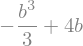

In [136]:
H0b = sp.integrate(hx, (x,0,b))
H0b

We can obtain the area $A_h(0,2)=\int_0^2 h(x)\,dx$
by using $A_h(0,2) = H_0(2) - H_0(0)$.

In [137]:
H0b.subs({b:2}) - H0b.subs({b:0})

Note SymPy calculated the exact value $\frac{16}{3} = 5.\overline{3}$
and not the floating point approximation $5.3333\ldots$.

### Applications of integration

Integrals are essential tools used in many areas of science, engineering, and business.

#### Kinematics

Calculus was originally invented
to describe the equations of motion $x(t)$, $v(t)$, and $a(t)$,
which correspond to an object's
*position*, *velocity*, and *acceleration* at time $t$.
We call these the *kinematics* equations,
from the Greek word *kinema* for motion.
The velocity function $v(t)$ is the derivative of the position function,
and the acceleration $a(t)$ is the derivative of the velocity.
We can summarize these relations as follows:
$$a(t) \overset{\frac{d}{dt} }{\longleftarrow} v(t) \overset{\frac{d}{dt} }{\longleftarrow} x(t).$$

Let's analyze the case where the net force on the object is constant.
A constant force causes a constant acceleration $a = \frac{F}{m} = \textrm{constant}$.
We find $v(t)$ by integrating $a(t)=a$.

In [138]:
t, a, v_i, x_i = sp.symbols('t a v_i x_i')

at = a  # a(t) = a (constant)
vt = v_i + sp.integrate(a, (t, 0,t) )
vt  # v(t)

We can now find $x(t)$ by integrating $v(t)$.

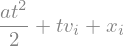

In [139]:
xt = x_i + sp.integrate(vt, (t,0,t))
xt  # x(t)

These two calculus steps
allow us to obtain the famous kinematics equation
for *uniform accelerated motion* (UAM):

\begin{align*}
 a(t) &= a,                                  \\ 
 v(t) &= v_i  + at,                          \\
 x(t) &= x_i + v_it + \tfrac{1}{2}at^2.
\end{align*}

You probably had to memorize these equations in your physics class,
bu now 
Now you know how to derive them from first principles.

#### Solving differential equations

A differential equation is an equation
that involves the derivatives of some unknown function $f(x)$.
Integration is very useful for solving differential equations.
For example,
to solve for $f(x)$ in the differential equation $\frac{d}{dx}f(x) = g(x)$,
we can take the integral on both sides of the equation
to obtain the answer $f(x) = \int g(x)\,dx + C$.

The SymPy function `sp.dsolve(diff_expr, <f>)`
allows us to solve the differential equation `diff_expr = 0`
for the unknown function `<f>`.
We'll now solve some differential equations using `sp.dsolve`.

##### Kinematics revisited

The kinematics equations when the acceleration is constant
come from the differential equation $x^{\prime\prime\!}(t) = a$,
which we can also write as $x^{\prime\prime\!}(t) - a = 0$.

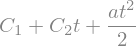

In [140]:
t, a = sp.symbols("t a")
x = sp.Function("x")
newton_eqn = sp.diff(x(t), t, t) - a
sp.dsolve(newton_eqn, x(t)).rhs

The solution is the same as the equation $x(t) = x_i + v_it + \tfrac{1}{2}at^2$
that we obtained earlier if we identify the integration
constants $C_1$ as the initial position $x_i$,
and $C_2$ as the initial velocity $v_i$.

##### Bacterial growth

In biology,
unconstrained bacterial growth is described by the equation $b^{\prime\!}(t) = kb(t)$,
where $b(t)$ is the number of bacteria at time $t$.

In [141]:
k = sp.symbols("k")
b = sp.Function("b")
bio_eqn = k*b(t) - sp.diff(b(t), t)
sp.dsolve(bio_eqn, b(t)).rhs

##### Radioactive decay

Radioactive decay is described by the differential equation
$r^{\prime\!}(t) = -\lambda r(t)$,
where $r(t)$ describes the number of atoms of some radioactive element.

In [142]:
lam = sp.symbols("\\lambda")
r = sp.Function("r")
radioactive_eqn = lam*r(t) + sp.diff(r(t), t)
sp.dsolve(radioactive_eqn, r(t)).rhs

##### Simple harmonic motion (SHM)

Simple harmonic motion is described by the
differential equation $x^{\prime\prime\!}(t) + \omega^2 x(t) = 0$.

In [143]:
w = sp.symbols("w", nonnegative=True)
SHM_eqn = sp.diff(x(t), t, t) + w**2*x(t)
sp.dsolve(SHM_eqn, x(t)).rhs

#### Probability calculations

Integration is required for computing probabilities of continuous random variables.
A continuous random variable $X$
is described by its *probability density function* $f_X$.
For example,
the standard normal random variable $Z$
is described by the probability density function
$f_Z(z) = \tfrac{1}{\sqrt{2\pi}} e^{ -\frac{1}{2}z^2 }$.

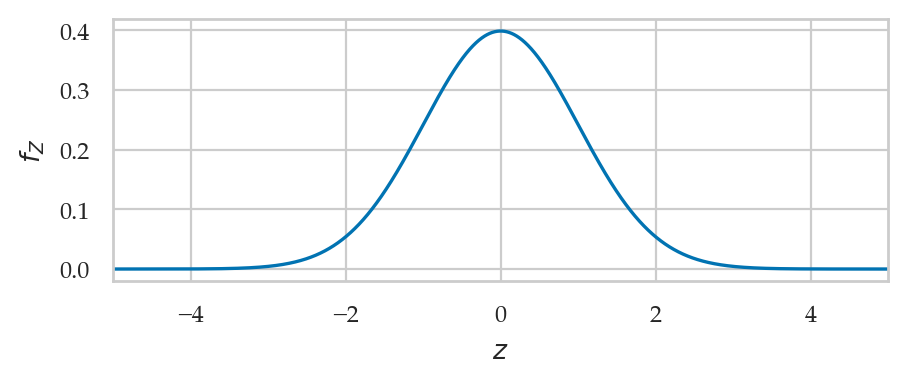

In [144]:
def fZ(z):
    return 1 / np.sqrt(2*np.pi) * np.exp(-z**2 / 2)

ax = plot_func(fZ, xlim=[-5,5])
ax.set_xlabel("$z$")
ax.set_ylabel("$f_Z$");

To compute the probability of the event $\{ a \leq X \leq b\}$,
we must find calculate the total probability density $f_X$
that falls between $x=a$ and $x=b$,
which is given by the integral: $\textrm{Pr}( \{ a \leq X \leq b\} ) = \int_a^b f_X(x) \, dx$.
For example,
the probability of the event $\{ -1 \leq Z \leq 1\}$
is given by $\int_{-1}^1 f_Z(z) \, dz$.

In [145]:
quad(fZ, a=-1, b=1)[0]

To probability of the event $\{ -2 \leq Z \leq 2\}$
is calculated as the integral $\int_{-2}^2 f_Z(z) \, dz$.

In [146]:
quad(fZ, a=-2, b=2)[0]

## Sequences and series

### Sequences are functions with discrete inputs

Instead of continuous inputs $x\in \mathbb{R}$,
sequences take natural numbers $k\in\mathbb{N}$ as inputs.
We denote sequences as $a_k$ instead of the usual function notation $a(k)$.

We can define a sequence by specifying an expression for its $k^\mathrm{th}$ term.

#### The natural numbers

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


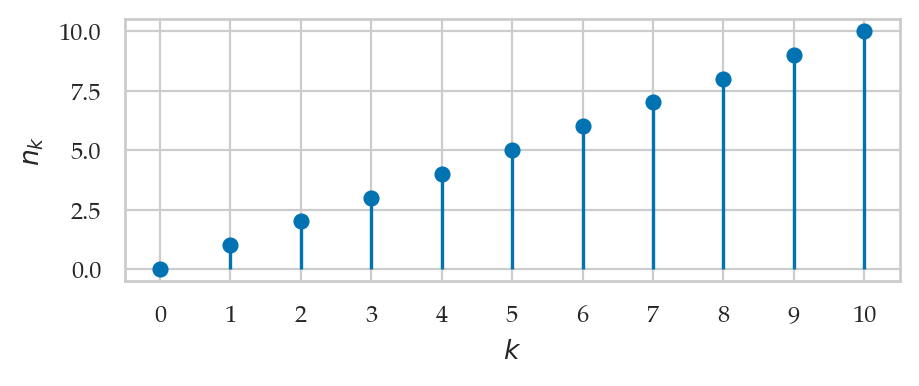

In [147]:
from ministats.calculus import plot_seq

def n_k(k):
    return  k

print([n_k(k) for k in range(0,11)])

plot_seq(n_k, start=0, stop=10, label="$n_k$");

We use a *stem plot* to represent the sequence $n_k$ graphically,
which shows it is only defined when $k$ is a natural number.

#### Squares of natural numbers

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


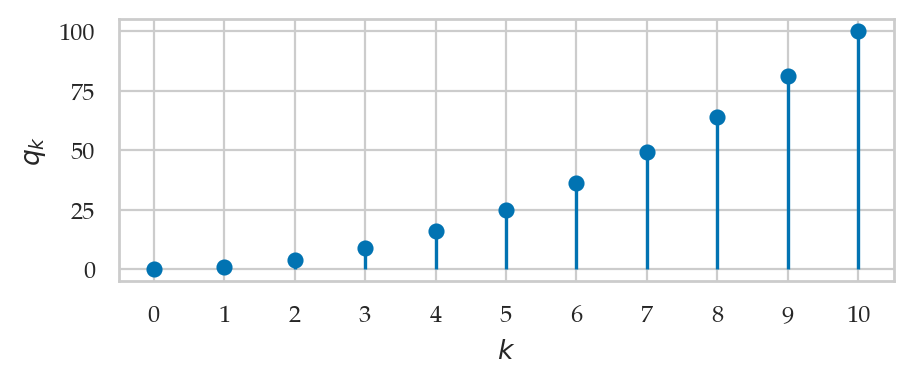

In [148]:
def q_k(k):
    return  k**2

print([q_k(k) for k in range(1,11)])

plot_seq(q_k, start=0, stop=10, label="$q_k$");

#### Harmonic sequence

[1.0, 0.5, 0.3333, 0.25, 0.2, 0.1667, 0.1429, 0.125, 0.1111]


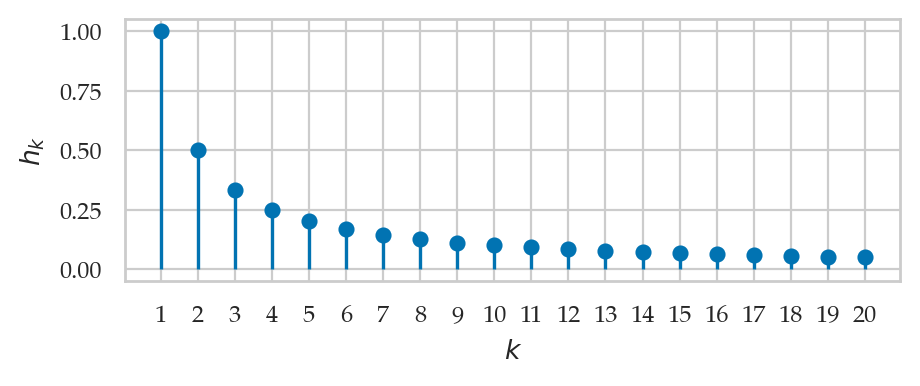

In [149]:
def h_k(k):
    return 1 / k

print([round(h_k(k),4) for k in range(1,10)])

plot_seq(h_k, start=1, stop=20, label="$h_k$");

#### The alternating harmonic sequence

[1.0, -0.5, 0.3333, -0.25, 0.2, -0.1667, 0.1429, -0.125, 0.1111]


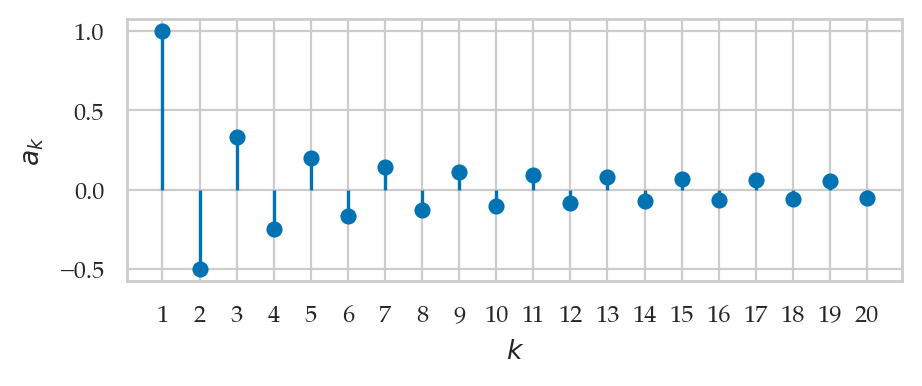

In [150]:
def a_k(k):
    return (-1)**(k+1) / k

print([round(a_k(k),4) for k in range(1,10)])

plot_seq(a_k, start=1, stop=20, label="$a_k$");

#### Inverse factorial sequence

[1.0, 1.0, 0.5, 0.166667, 0.041667, 0.008333, 0.001389, 0.000198, 2.5e-05, 3e-06]


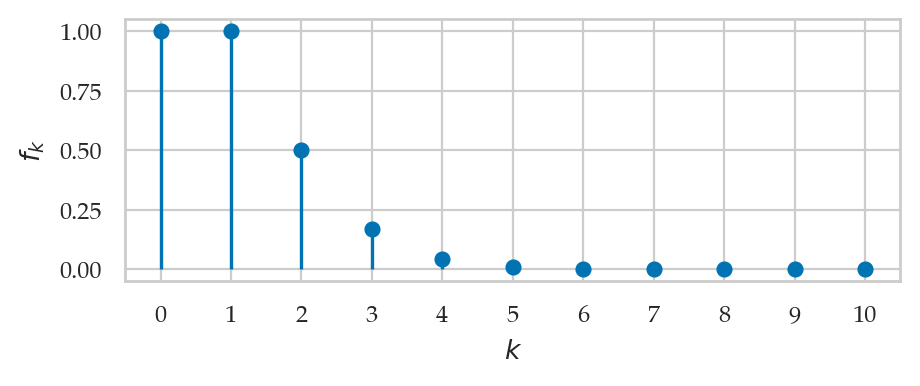

In [151]:
import math

def f_k(k):
    return 1 / math.factorial(k)

print([round(f_k(k),6) for k in range(0,10)])

plot_seq(f_k, start=0, stop=10, label="$f_k$");

#### Geometric sequence

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.01562, 0.00781, 0.00391, 0.00195, 0.00098]


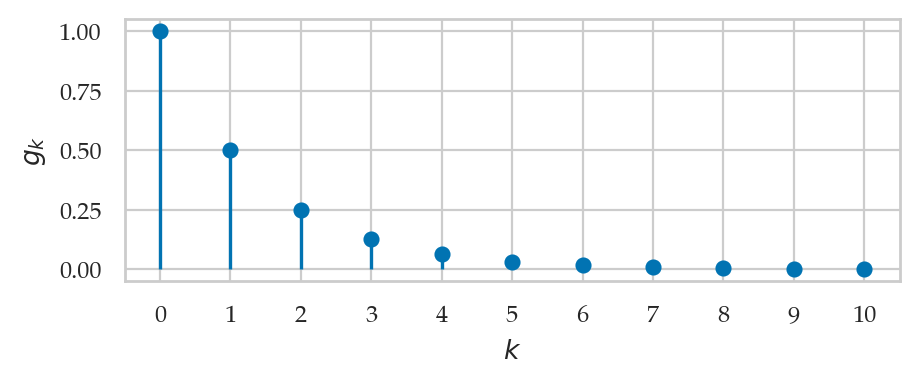

In [152]:
def g_k(k, r=0.5):
    return r**k

print([round(g_k(k),5) for k in range(0,11)])

plot_seq(g_k, start=0, stop=10, label="$g_k$");

#### Powers of two

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


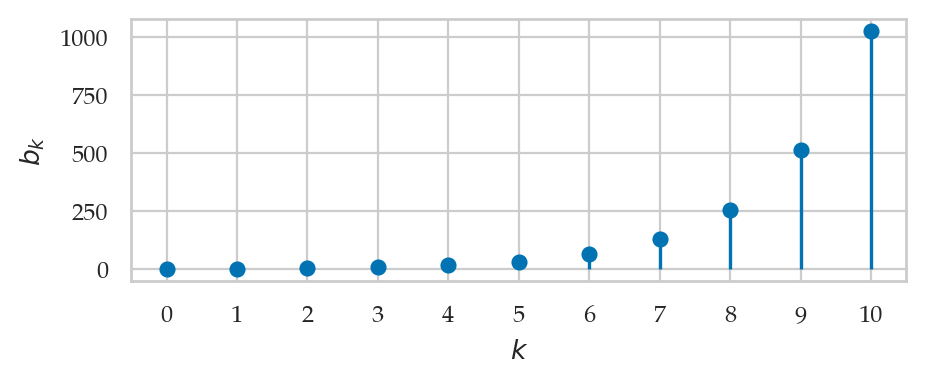

In [153]:
def b_k(k):
    return 2**k

print([b_k(k) for k in range(0,11)])

plot_seq(b_k, start=0, stop=10, label="$b_k$");

### Convergence of sequences

What happens to a sequence as $k$ goes to infinity?
We use the limit notation $\lim_{k \to \infty}$ to describe this process.
There are two behaviours we're interested in:
sequences that blow up to infinity,
and sequences that converge to some finite value.

#### Divergent sequences

The sequences $n_k = k$, $q_k = k^2$, and $b_k = 2^k $
keep getting larger and larger as $k$ goes to infinity.

In [154]:
k = sp.symbols("k")

sp.limit(k, k, sp.oo)

In [155]:
sp.limit(k**2, k, sp.oo)

In [156]:
sp.limit(2**k, k, sp.oo)

#### Convergent sequences

The sequences $h_k = \tfrac{1}{k}$,
$a_k = \tfrac{(-1)^{k+1}}{k}$,
and $f_k = \tfrac{1}{k!}$ *converge* to  $0$ in the limit as $k$ goes to infinity.

In [157]:
sp.limit(1/k, k, sp.oo)

In [158]:
sp.limit_seq((-1)**(k+1)/k, k)

In [159]:
sp.limit(1/sp.factorial(k), k, sp.oo)

### Summation notation

The capital Greek letter *sigma* stands in for the word *sum*,
and the range of index values included in this sum is denoted below and above
the summation sign.
For example,
the sum of the values in the sequence $c_k$ from $k=0$ until $k=n$
is denoted 

$$\sum_{k=0}^n c_k =  c_0 + c_1 + c_2 + \cdots + c_{n-1} + c_n.$$

### Exact formulas for finite sums

We'll now show some useful formulas for calculating the sums of certain sequences. 


#### Geometric sums
The formula for the sum of the first $n$ terms in the geometric sequence is

$$ G_n = \sum_{k=0}^n r^k 
       = 1 + r + r^2 + \cdots + r^n 
       = \frac{1-r^{n+1}}{1-r}.$$

Let's verify this using SymPy.
To work with series,
use the `sp.summation` function whose syntax is analogous to the `sp.integrate` function.

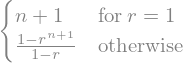

In [160]:
r, n = sp.symbols("r n")
sp.summation(r**k, (k,0,n))

We can use this formula to
find the sum of the powers of $2$:

$$\sum_{k=0}^n 2^k = 1 + 2 + 4 + 8 + \cdots + 2^n = \frac{1-2^{n+1}}{1-2} = 2^{n+1} -1.$$

In [161]:
sp.summation(2**k, (k,0,n))

#### Arithmetic sums
The sum of the first $n$ positive integers and the sum of their squares
are described by the following formulas:

$$\sum_{k=1}^n k = \frac{n(n+1)}{2}
            \qquad \text{and} \qquad
            \sum_{k=1}^n k^2=\frac{n(n+1)(2n+1)}{6}.$$

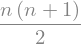

In [162]:
sp.simplify(sp.summation(k, (k,0,n)))

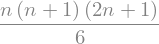

In [163]:
sp.factor(sp.summation(k**2, (k,0,n)))

#### Sums of binomial coefficients

The *binomial coefficient* is denoted ${n \choose k}$,
which is read as "$n$ choose $k$." The binomial coefficient counts the
number of combinations of $k$ items we can choose from a set of $n$
items, and it is computed using the formula:

$${n \choose k} = \frac{n!}{(n-k)! \, k!}.$$

For example,
the number of combinations of size $2$ selected from a list of $5$ items is

$${5 \choose 2}  = \frac{5!}{(5-2)!\,2!} = \frac{5!}{3!\,2!}
                        = \frac{5\cdot 4 \cdot 3 \cdot 2 \cdot 1}{3 \cdot 2 \cdot 1 \;\; \cdot \;\; 2 \cdot 1  } 
                        = \frac{120}{6 \cdot 2} = 10.$$
                        
The binomial
coefficient appears in the expansion of the binomial expression
$(a + b)^n$, which can written as the following sum:

$$\begin{aligned}
                (a+b)^n &= {n \choose 0}a^n
                            + {n \choose 1}a^{n-1}b 
                            % + {n \choose 2}a^{n-2}b^2
                            + \cdots
                            + {n \choose n-1 }ab^{n-1}
                            + {n \choose n}b^n  \\
                        &= \sum_{k=0}^n {n \choose k} a^{n-k} b^k.
\end{aligned}$$

This sum appears in certain calculations in probability theory.

### Series

Series are defined as the sums computed from the terms in the sequence $c_k$.
The *finite series* $\sum_{k=1}^n c_k$ computes the first $n$
terms of the sequence:

$$C_n = \sum_{k=1}^n c_k
                = c_1 + c_2 + c_3 + c_4 + c_5  + \cdots  + c_{n-1} + c_n.$$

The *infinite series* $\sum c_k$ computes *all* the terms in the sequence:

$$C_\infty    = \lim_{n\to \infty} C_n
                    = \lim_{n\to \infty}  \sum_{k=1}^n c_k
                    = c_1 + c_2 + c_3 + c_4 + c_5 + \cdots.$$
                    
The infinite series $\sum c_k$ of the sequence
$c_k : \mathbb{N} \to \mathbb{R}$ is analogous to the integral
$\int_0^\infty f(x) \,dx$ of a function $f : \mathbb{R} \to \mathbb{R}$.


Some infinite series converge to a finite value. For example, when
$|r|<1$, the limit as $n \to \infty$ of the geometric series converges
to the following value:

$$G_\infty 
                = \lim_{n \to \infty} G_n 
                = \sum_{k=0}^\infty r^k
                = 1 + r + r^2 +  r^3 + \cdots 
                = \frac{1}{1-r}.$$
                
This expression describes an infinite
sum, which is not possible to compute in practice, but we can see the
truth of this equation using our mind's eye. The formula for first $n$
terms is the geometric series is $G_n = \frac{1-r^{n+1}}{1-r}$. The term
$r^{n+1}$ goes to zero as $n \to \infty$, so the only part of the
formula that remains is $\frac{1}{1-r}$.


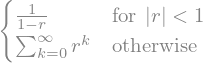

In [164]:
r = sp.symbols("r")
sp.summation(r**k, (k,0,sp.oo))

#### Example 16: sum of a geometric series

We can represent the series as the area of the rectangles of width one
constructed from the values of the sequences.

The sum of the first 11 terms of the sequence is 1.999023


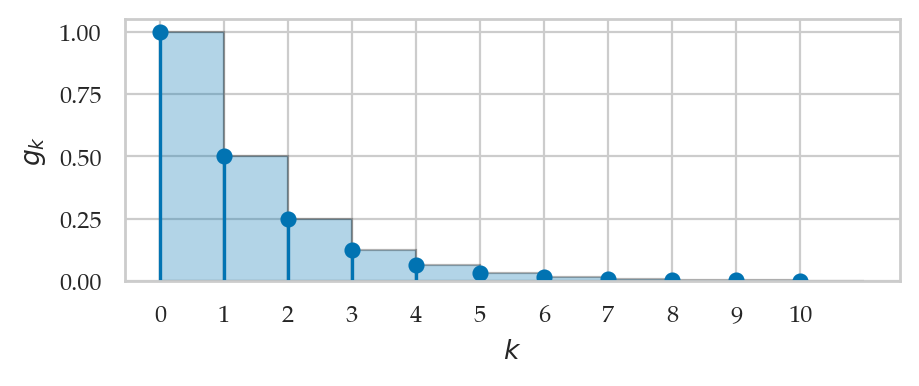

In [165]:
from ministats.calculus import plot_series

def g_k(k):
    return (1/2)**k

plot_series(g_k, start=0, stop=10, label="$g_k$");

Let's evaluate the partial sums
of the sequence to see how quickly the series converges.

In [166]:
sum([g_k(k) for k in range(0, 10)])

In [167]:
sum([g_k(k) for k in range(0, 20)])

In [168]:
sum([g_k(k) for k in range(0, 100)])

We can compute the infinite sum using SymPy.

In [169]:
sp.summation((1/2)**k, (k,0,sp.oo))

#### Convergent and divergent series

We say the geometric series
$G_\infty = \sum_{k=0}^\infty r^k$ *converges* to the value $\frac{1}{1-r}$.
We can also say that the infinite geometric series
$\sum_{k=1}^\infty g_k$ *is convergent*, meaning it has a finite value and doesn't
blow up. Another example of a converging infinite series is
$F_\infty = \sum_{k=0}^\infty f_k$, which converges to the number $e$, as we'll see
in Example 17 below.

In contrast, the harmonic series $H_\infty = \sum_{k=1}^\infty h_k$ *diverges*. When we sum
together more and more terms of the sequences $h_k$, the total computed
keeps growing and the infinite series blows up to infinity
$H_\infty = \sum_{k=1}^\infty h_k = \infty$. We say that the harmonic series *is divergent*.

In [170]:
for n in [20, 100, 1000, 10000, 1_000_000]:
    H_n = sum([h_k(k) for k in range(1, n)])
    print("Harmonic series up to n=", n, "is", H_n)

Harmonic series up to n= 20 is 3.5477396571436817
Harmonic series up to n= 100 is 5.17737751763962
Harmonic series up to n= 1000 is 7.484470860550345
Harmonic series up to n= 10000 is 9.787506036044382
Harmonic series up to n= 1000000 is 14.392725722865723


In [171]:
sp.summation(1/k, (k,1,sp.oo))

#### Using convergent series for practical calculations

#### Example 17: Euler's number

The infinite sum of the sequence $f_k = \tfrac{1}{k!}$ converges to
Euler's number $e = 2.71828182845905\ldots$:

$$F_\infty 
    = \lim_{n \to \infty} F_n 
    = \sum_{k=0}^\infty \tfrac{1}{k!}
    = 1 + 1 + \tfrac{1}{2} + \tfrac{1}{6} + \tfrac{1}{24} + \tfrac{1}{720} + \cdots
    = e.
    % = 2.71828\ldots.$$

The calculation above is not just cool math fact, but a useful
computational procedure that we can use to approximate the value of
$e = 2.71828\ldots$ using only basic arithmetic operations like repeated
multiplication (factorial), division, and addition.

Let's start with a visualization of the series.

The sum of the first 11 terms of the sequence is 2.718282


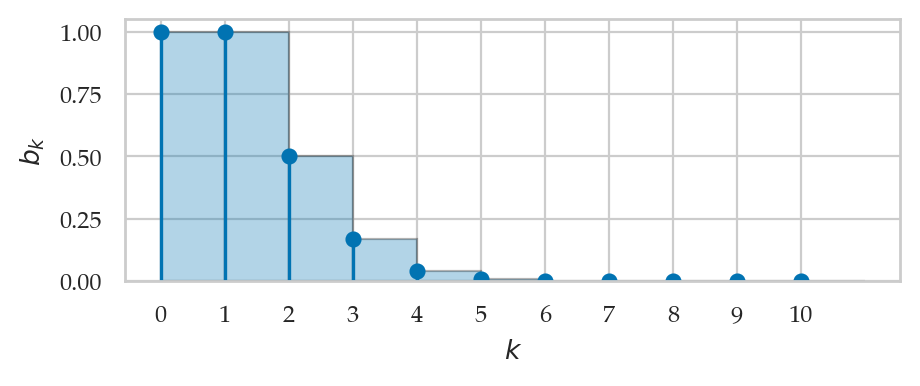

In [172]:
import math

def f_k(k):
    return 1 / math.factorial(k)

plot_series(f_k, start=0, stop=10, label="$b_k$");

Using a Python `for`-loop,
we can obtain an approximation to $e$ that is accurate to six decimals by summing 10 terms in the series:

In [173]:
sum([f_k(k) for k in range(0, 10)])

The approximation becomes more accurate as we sum together additional terms.

In [174]:
sum([f_k(k) for k in range(0, 15)])

In [175]:
sum([f_k(k) for k in range(0, 20)])

The approximation we obtain using 20 terms in a series
is a very close approximation to the exact value.

In [176]:
import math
math.e

We can use the SymPy function `sp.summation`
to compute the infinite sum symbolically.

In [177]:
sp.summation(1/sp.factorial(k), (k,0,sp.oo))

#### Example 18: Natural logarithm of 2

We can calculate the value $\ln(2)$
by computing the infinite sum of the alternating harmonic sequence
$a_k = \tfrac{(-1)^{k+1}}{k}$:

$$A_\infty
                        = \lim_{n \to \infty} \sum_{k=1}^n \tfrac{(-1)^{k+1}}{k}
                         = 1 - \tfrac{1}{2} + \tfrac{1}{3} - \tfrac{1}{4} + \tfrac{1}{5} - \tfrac{1}{6}  + \cdots
                        = \ln(2).$$

In [178]:
def a_k(k):
    return (-1)**(k+1) / k

for n in [10, 100, 1000, 1_000_000]:
    A_n = sum([a_k(k) for k in range(1,n+1)])
    print("Alternating geometric series up to n=", n, "is", A_n)

Alternating geometric series up to n= 10 is 0.6456349206349206
Alternating geometric series up to n= 100 is 0.6881721793101953
Alternating geometric series up to n= 1000 is 0.6926474305598203
Alternating geometric series up to n= 1000000 is 0.6931466805601953


In [179]:
math.log(2)

In [180]:
sp.summation((-1)**(k+1) / k, (k,1,sp.oo))

### Power series

The term *power series* describes a series whose terms contain different
powers of the variable $x$. The $k$the term in a power series consists
of some coefficient $c_k$ and the $k$th power of $x$:

$$P_n(x)
    = \sum_{k=0}^n c_k x^k
    = c_0 + c_1x + c_2x^2 + c_3x^3 % + c_4x^4 + c_5x^5
        + \cdots + c_nx^n.$$
                    
                    
The math expression we obtain
in this way is a *polynomial* of degree $n$ in $x$, which we denote
$P_n(x)$. Depending on the choice of the coefficients
$(c_0, c_1, c_2, c_3, \ldots, c_n)$ we can make the polynomial function
$P_n(x)$ *approximate* some other function
$f : \mathbb{R} \to \mathbb{R}$. To find such approximations, we need
some way to choose the coefficients $c_k$ of the power series, so that
the resulting polynomial approximates the function:
$P_n(x) \approx f(x)$.

### Taylor series

The *Taylor series approximation* to the function $f(x)$ is a power
series whose coefficients $c_k$ are computed by evaluating the $k$th
derivative of the function $f(x)$ at $x=0$,
which we denote $f^{(k)}(0)$.
Specifically, the $k$th coefficient in the Taylor series approximation for the function $f(x)$ is
$c_k = \frac{f^{(k)}(0)}{k!}$, where $k!$ is the factorial
function.

The finite Taylor series with $n$ terms produces the following approximation:

\begin{align*}
f(x)
    &\approx f(0)
        +f^{\prime\!}(0)x
        +\tfrac{f^{\prime\prime}(0)}{2!}x^2
        % +\tfrac{f^{(3)}(0)}{3!}x^3
        + \cdots
        +\tfrac{f^{(n)}(0)}{n!}x^n  \\
        % +\tfrac{f^{\prime\prime\prime}(0)}{3!}x^3
        % +\tfrac{f^{(4)}(0)}{4!}x^4 + \cdots \\
    &= \sum_{k=0}^n \tfrac{f^{(k)}(0)}{k!}x^k.
\end{align*}
                
In the limit as $n$ goes to infinity,
the Taylor series approximation becomes exactly equal to the function $f(x)$:

\begin{align*}
f(x) &= f(0) + f^{\prime\!}(0)x
            + \tfrac{f^{\prime\prime}(0)}{2!}x^2
            + \tfrac{f^{(3)}(0)}{3!}x^3 + \cdots \\
        &= \sum_{k=0}^\infty \tfrac{f^{(k)}(0)}{k!}x^k.
\end{align*}
        
Using this formula and your knowledge of derivative formulas,
you can compute the Taylor series of any function $f(x)$.
For example, let's find the
Taylor series of the function $f(x) = e^x$ at $x=0$. The first
derivative of $f(x) = e^x$ is $f^{\prime\!}(x) = e^x$. The second
derivative of $f(x) = e^x$ is $f^{\prime\prime\!}(x) = e^x$. In fact,
all the derivatives of $f(x)$ will be $e^x$ because the derivative of
$e^x$ is equal to $e^x$. The $k$th coefficient in the power series of
$f(x)=e^x$ at the point $x=0$ is equal to the value of the $k$th
derivative of $f(x)$ evaluated at $x=0$ divided by $k!$. In the case of
$f(x) = e^x$, we have $f^{(k)}(0) = e^0 = 1$.
The coefficient of the $k$th term
is $c_k = \tfrac{f^{(k)}(0)}{k!}  = \tfrac{1}{k!}$,
so the Taylor series of $f(x) = e^x$ is

$$e^x = \sum_{k=0}^\infty \tfrac{1}{k!}x^k
                = 1 + x + \tfrac{x^2}{2} + \tfrac{x^3}{3!}
                    + \tfrac{x^4}{4!} + \tfrac{x^5}{5!} 
                    + \tfrac{x^6}{6!} + \tfrac{x^7}{7!}  + \cdots$$

Taylor series are a powerful computational tool for approximating
functions. As we compute more terms from the above series, the
polynomial approximation to the function $f(x)=e^x$ becomes more
accurate.

### Obtaining Taylor series using SymPy

The SymPy function `series` is a convenient way to obtain the series of any function `fun`.
Calling `sp.series(fun,var,x0,n)` 
will show you the series expansion of `expr` 
near `var`=`x0` including all powers of `var` less than `n`.

In [181]:
import sympy as sp
x = sp.symbols("x")

sp.series(1/(1-x), x, x0=0, n=8)

In [182]:
sp.series(1/(1+x), x, x0=0, n=8)

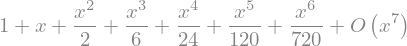

In [183]:
sp.series(sp.E**x, x, x0=0, n=7)

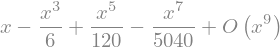

In [184]:
sp.series(sp.sin(x), x, x0=0, n=9)

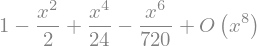

In [185]:
sp.series(sp.cos(x), x, x0=0, n=8)

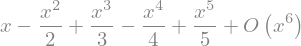

In [186]:
sp.series(sp.ln(x+1), x, x0=0, n=6)

### Applications of series

Series allow us to compute numbers like $e$, $\pi$, $\ln(2)$, etc.
Taylor series allow us to approximate functions $e^x$,
$\sin(x)$, $\cos(x)$, etc.

The Taylor series representation for the function $f(x)$
provides an easy way to
compute its integral function $F_0(x) = \int_0^x f(u)\,du$.
The Taylor series $f(x) = \sum_{k=0}^\infty c_k x^k$
consists only of polynomial terms of the form $c_k x^k$.
To compute the integral function
$F_0$, we can compute the integral of each term,
which is $\int c_k x^k \,dx = \frac{c_k}{k+1}x^{k+1}$.
This means the Taylor series 
of the integral function is $F_0(x) = \sum_{k=0}^\infty \frac{c_k}{k+1}x^{k+1} + C$.

## Advanced calculus

## Solutions to practice problems

Learning calculus requires calculating lots of limits, derivatives, and integrals.
Here are some practice problems for you.

**P1** Calculate the following limit expressions:

$$\text{(a)}~\lim_{x\to \infty} \tfrac{7}{x+4}
            \qquad
            \text{(b)}~\lim_{x\to\infty}\tfrac{4x^2-7x+1}{x^2}
            \qquad
            \text{(c)}~\lim_{x\to 0^-} \tfrac{1}{x}$$

In [187]:
import sympy as sp
x = sp.symbols("x")

# (a)
sp.limit(7/(x+4), x, sp.oo)

In [188]:
# (b)
sp.limit((4*x**2-7*x+1)/ x**2, x, sp.oo)

In [189]:
# (c)
sp.limit(1/x, x, 0, "-")

**P2** Assuming
$\displaystyle\lim_{x\to\infty} f(x)= 2$ and
$\displaystyle\lim_{x\to\infty} g(x)=3$, compute:
$$\text{(a)}~\!\!\lim_{x\to\infty}\bigl(2f(x)-g(x)\bigr)
            \quad
            \text{(b)}~\!\!\lim_{x\to\infty} f(x)g(x)
            \quad
            \text{(c)}~\!\!\lim_{x\to\infty}\tfrac{4f(x)}{g(x)+1}$$

**P3** Find the derivative with respect to $x$ of the functions:
$$\text{(a)}~f(x) = x^{13}
            \qquad
            \text{(b)}~g(x) = \sqrt[3]{x}
            \qquad
            \text{(c)}~h(x) =  ax^2 + bx + c$$

In [190]:
# (a)
sp.diff(x**13)

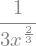

In [191]:
# (b)
sp.diff(sp.root(x,3), x)

In [192]:
# (c)
a, b, c = sp.symbols("a b c")
sp.diff(a*x**2 + b*x + c, x)

**P4** Calculate the derivatives of the following functions:
$$\text{(a)}~p(x) = \tfrac{2x + 3}{3x + 2}
            \qquad
            \text{(b)}~q(x) = \sqrt{x^2 + 1}
            \qquad
            \text{(c)}~r(\theta) =  \sin^3 \theta$$

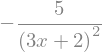

In [193]:
# (a)
sp.together(sp.diff((2*x+3)/(3*x+2), x))

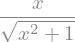

In [194]:
# (b)
sp.diff(sp.sqrt(x**2+1), x)

In [195]:
# (c)
sp.diff((sp.sin(x))**3, x)

**P5** Find the maximum and the minimum of $f(x) = x^5-5x$.

In [196]:
x = sp.symbols("x", real=True)
fx = x**5 - 5*x
dfdx = sp.diff(fx, x)
sols = sp.solve(dfdx, x)
sols

In [197]:
df2dx2 = sp.diff(fx, x, x)
print("When x =", sols[0], ", f''(-1) =", df2dx2.subs({x:sols[0]}), "so maximum")

When x = -1 , f''(-1) = -20 so maximum


In [198]:
print("When x =", sols[1], ", f''(1) =", df2dx2.subs({x:sols[1]}), "so minimum")

When x = 1 , f''(1) = 20 so minimum


**P6** Calculate the integral function $F_0(b) = \int_0^b f(x)\,dx$ for
the polynomial $f(x) = 4x^3 + 3x^2 + 2x + 1$.

In [199]:
F0b = sp.integrate(4*x**3 + 3*x**2 + 2*x + 1, (x,0,b))
F0b

**P7** Find the area under $f(x)=8-x^3$ from $x=0$ to $x=2$.

In [200]:
from scipy.integrate import quad

def fcubic(x):
    return 8 - x**3

quad(fcubic, a=0, b=2)[0]

**P8** Find the area under the graph of the function $g(x)=\sin(x)$
between $x=0$ to $x=\pi$.

In [201]:
quad(np.sin, a=0, b=np.pi)[0]

**P9** Compute $\int_{0}^{1} \frac{4x}{(1+x^2)^3}\,dx$ using the
substitution $u = 1 + x^2$. Check your answer numerically using the
SciPy function `quad`.

In [202]:
sp.integrate(4*x/(1+x**2)**3, (x,0,1))

**P10** Calculate the value of the infinite series
$\sum_{k=0}^\infty  \left(\frac{2}{3}\right)^{\!k}$.

In [203]:
sp.summation((2/3)**k, (k,0,sp.oo))

**P11** Find the Taylor series for the function $f(x) = e^{-x}$.

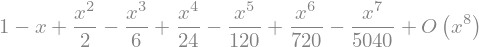

In [204]:
sp.series(sp.exp(-x), x, 0, 8)

## Links

Here are some recommended resources to learn more about calculus.

[ Calculus for beginners and srtists ]   
https://math.mit.edu/~djk/calculus_beginners/   
via https://news.ycombinator.com/item?id=41086531 

[ Jim Fowler video lectures ]  
https://www.youtube.com/@kisonecat/playlists 

[ Highlights of Calculus lectures by Gilbert Strang ]  
https://www.youtube.com/playlist?list=PLBE9407EA64E2C318 

[ Nice visualization of integration ]  
https://x.com/abakcus/status/1898933342457758033 


## Book plug

This material in this tutorial comes from ...